In [1]:
# %pip install kagglehub lightgbm xgboost scikit-learn scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    accuracy_score, f1_score, mean_squared_error, r2_score,
    roc_curve, auc
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from scipy.stats import entropy
import joblib

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130

os.makedirs("../visualizations/soil_prediction/eda",    exist_ok=True)
os.makedirs("../visualizations/soil_prediction/models", exist_ok=True)
os.makedirs("../models/soil_prediction",                exist_ok=True)

print("All imports successful.")


All imports successful.


In [3]:
import kagglehub

path = kagglehub.dataset_download("shankarpriya2913/crop-and-soil-dataset")
df = pd.read_csv(os.path.join(path, "data_core.csv"))
df.columns = df.columns.str.strip()

print(f"Shape: {df.shape}")
df.head()


Shape: (8000, 9)


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26.0,52.0,38.0,Sandy,Maize,37,0,0,Urea
1,29.0,52.0,45.0,Loamy,Sugarcane,12,0,36,DAP
2,34.0,65.0,62.0,Black,Cotton,7,9,30,14-35-14
3,32.0,62.0,34.0,Red,Tobacco,22,0,20,28-28
4,28.0,54.0,46.0,Clayey,Paddy,35,0,0,Urea


In [4]:
print("=== Shape ===")
print(df.shape)

print("\n=== Data Types & Nulls ===")
df.info()

print("\n=== Descriptive Statistics ===")
df.describe(include="all").T


=== Shape ===
(8000, 9)

=== Data Types & Nulls ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temparature      8000 non-null   float64
 1   Humidity         8000 non-null   float64
 2   Moisture         8000 non-null   float64
 3   Soil Type        8000 non-null   object 
 4   Crop Type        8000 non-null   object 
 5   Nitrogen         8000 non-null   int64  
 6   Potassium        8000 non-null   int64  
 7   Phosphorous      8000 non-null   int64  
 8   Fertilizer Name  8000 non-null   object 
dtypes: float64(3), int64(3), object(3)
memory usage: 562.6+ KB

=== Descriptive Statistics ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Temparature,8000.0,NaN,NaN,NaN,30.338895,4.478262,20.0,27.05,30.24,33.46,40.0
Humidity,8000.0,NaN,NaN,NaN,59.210731,8.177366,40.02,53.2775,59.11,65.0825,80.0
Moisture,8000.0,NaN,NaN,NaN,43.580862,12.596156,20.0,33.9675,42.25,52.95,70.0
Soil Type,8000,5,Clayey,1623,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop Type,8000,11,Sugarcane,763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nitrogen,8000.0,NaN,NaN,NaN,18.429125,11.852406,0.0,9.0,14.0,26.0,46.0
Potassium,8000.0,NaN,NaN,NaN,3.916375,5.494807,0.0,0.0,1.0,5.0,23.0
Phosphorous,8000.0,NaN,NaN,NaN,18.5125,13.244113,0.0,8.0,18.0,30.0,46.0
Fertilizer Name,8000,7,14-35-14,1188,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values per column:
Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64

Duplicate rows: 0


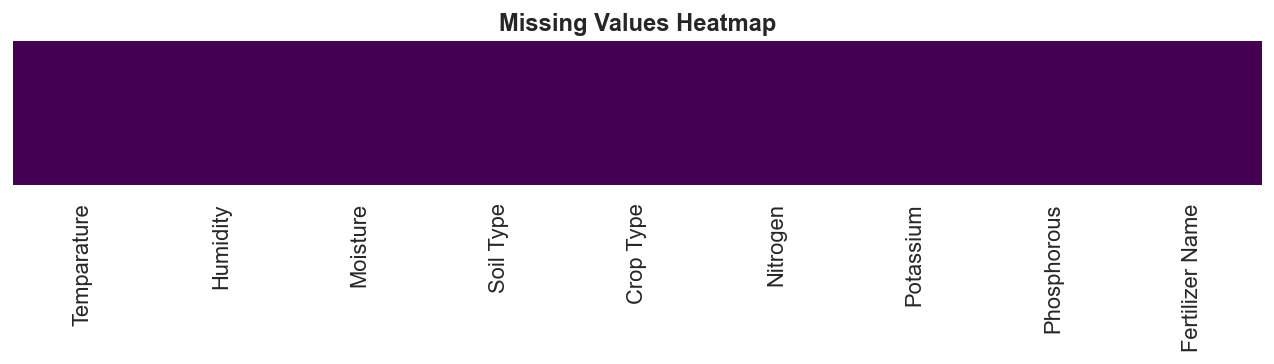

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis", ax=ax)
ax.set_title("Missing Values Heatmap", fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/eda/01_missing_values.png", bbox_inches="tight")
plt.show()


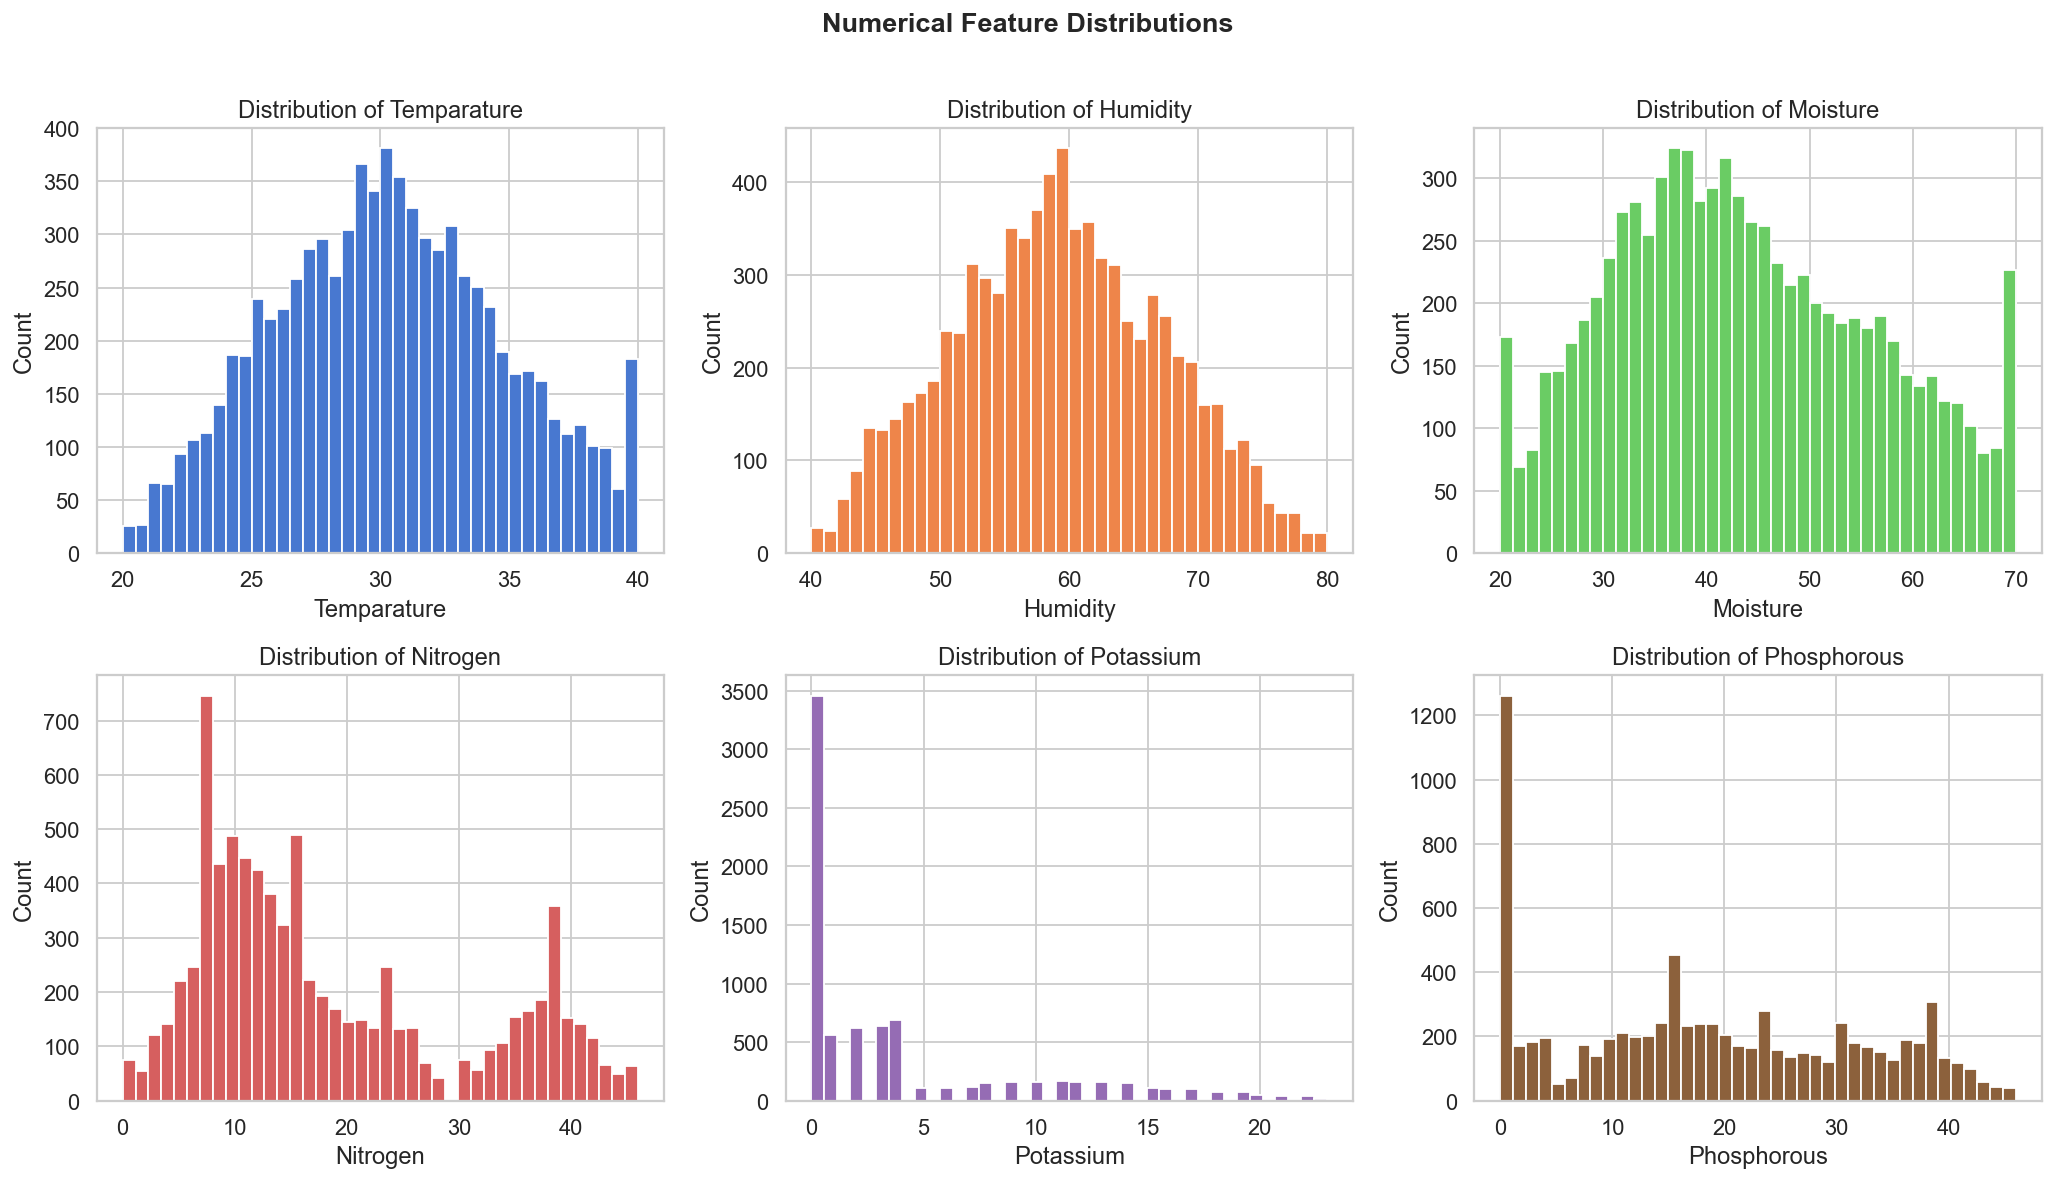

In [6]:
num_cols = ["Temparature", "Humidity", "Moisture", "Nitrogen", "Potassium", "Phosphorous"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, edgecolor="white", color=sns.color_palette("muted")[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.suptitle("Numerical Feature Distributions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/eda/02_numerical_distributions.png", bbox_inches="tight")
plt.show()


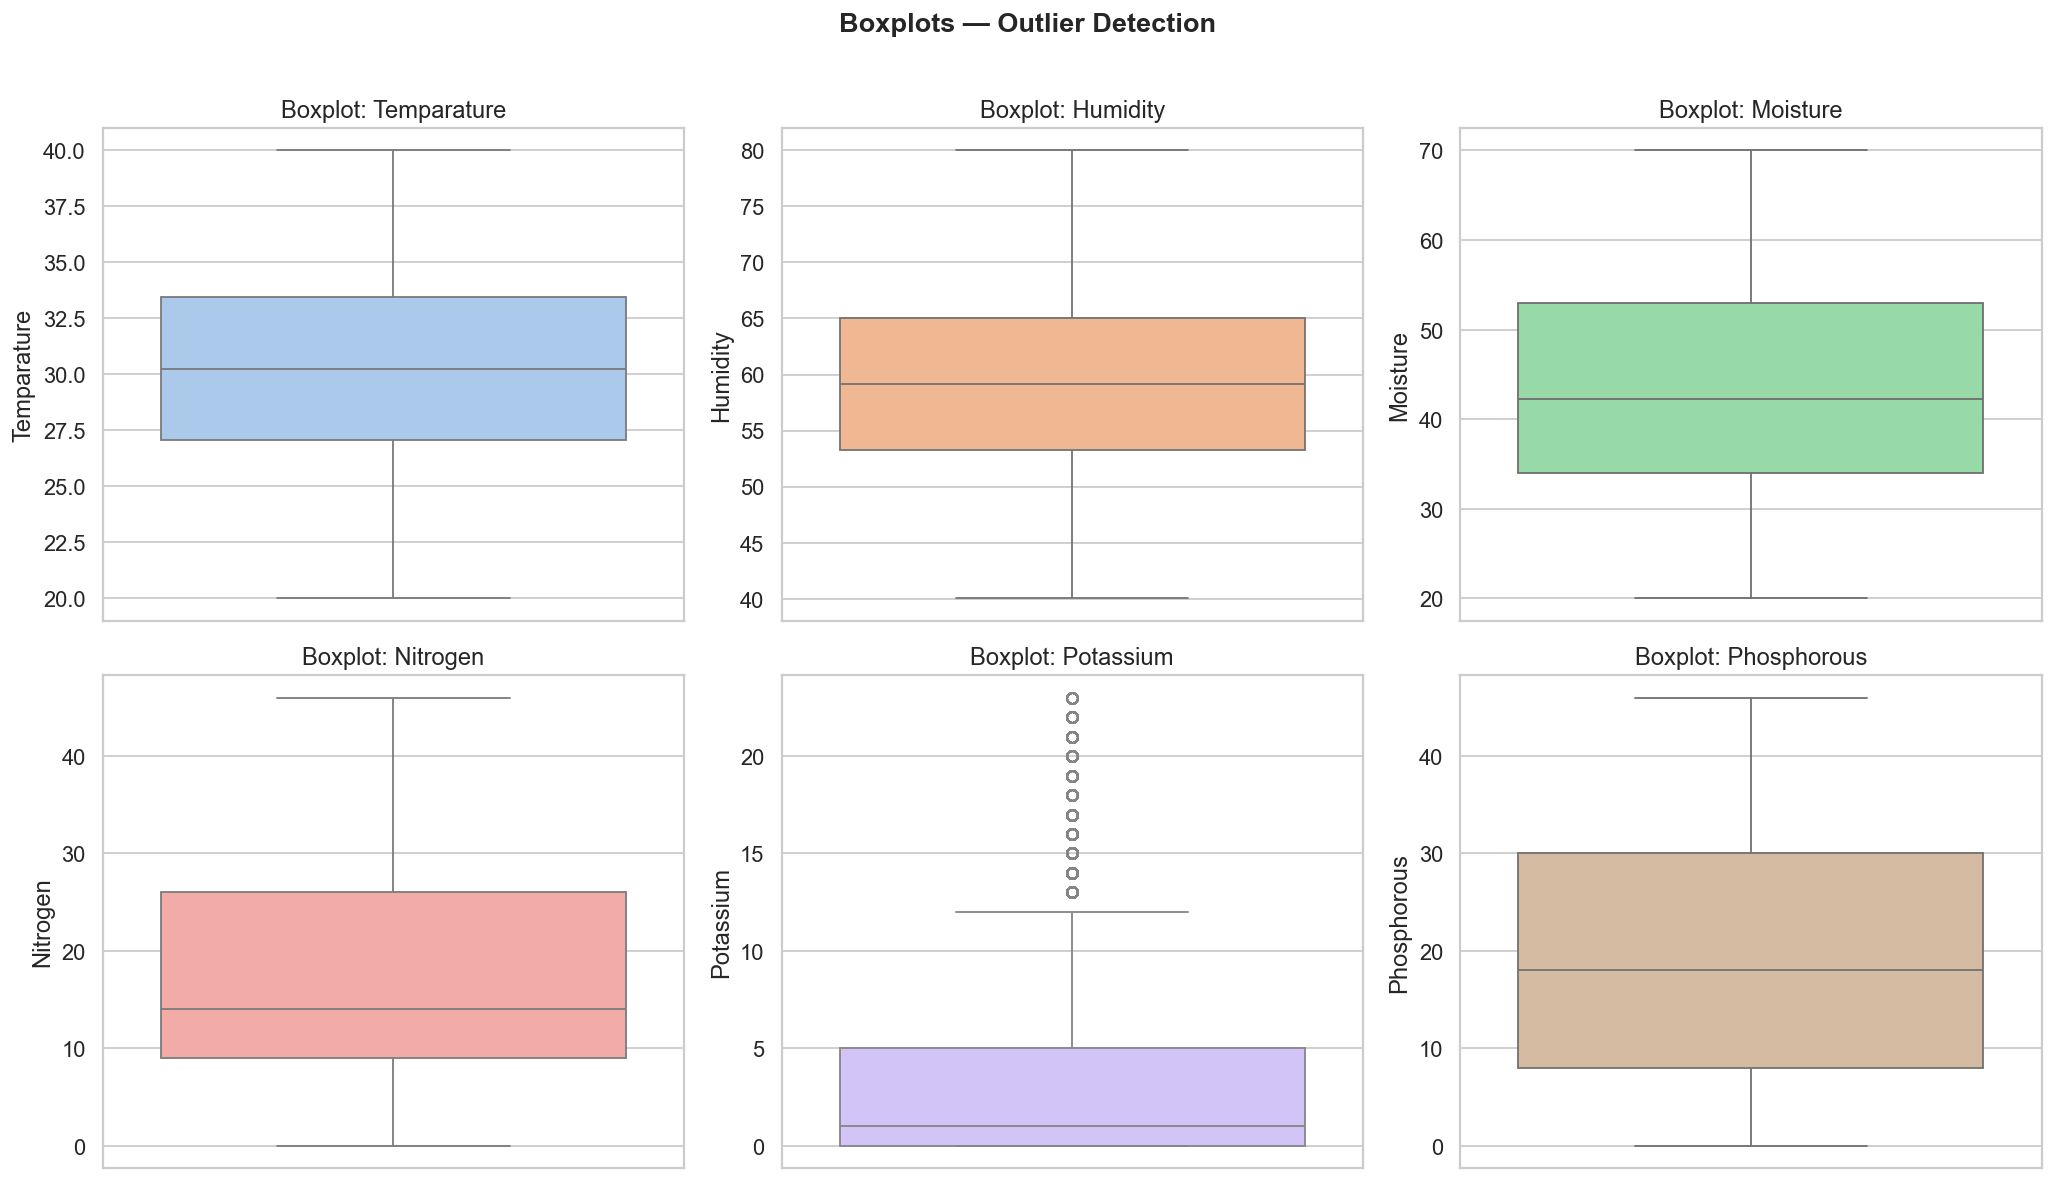

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=sns.color_palette("pastel")[i])
    axes[i].set_title(f"Boxplot: {col}")

plt.suptitle("Boxplots — Outlier Detection", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/eda/03_boxplots.png", bbox_inches="tight")
plt.show()


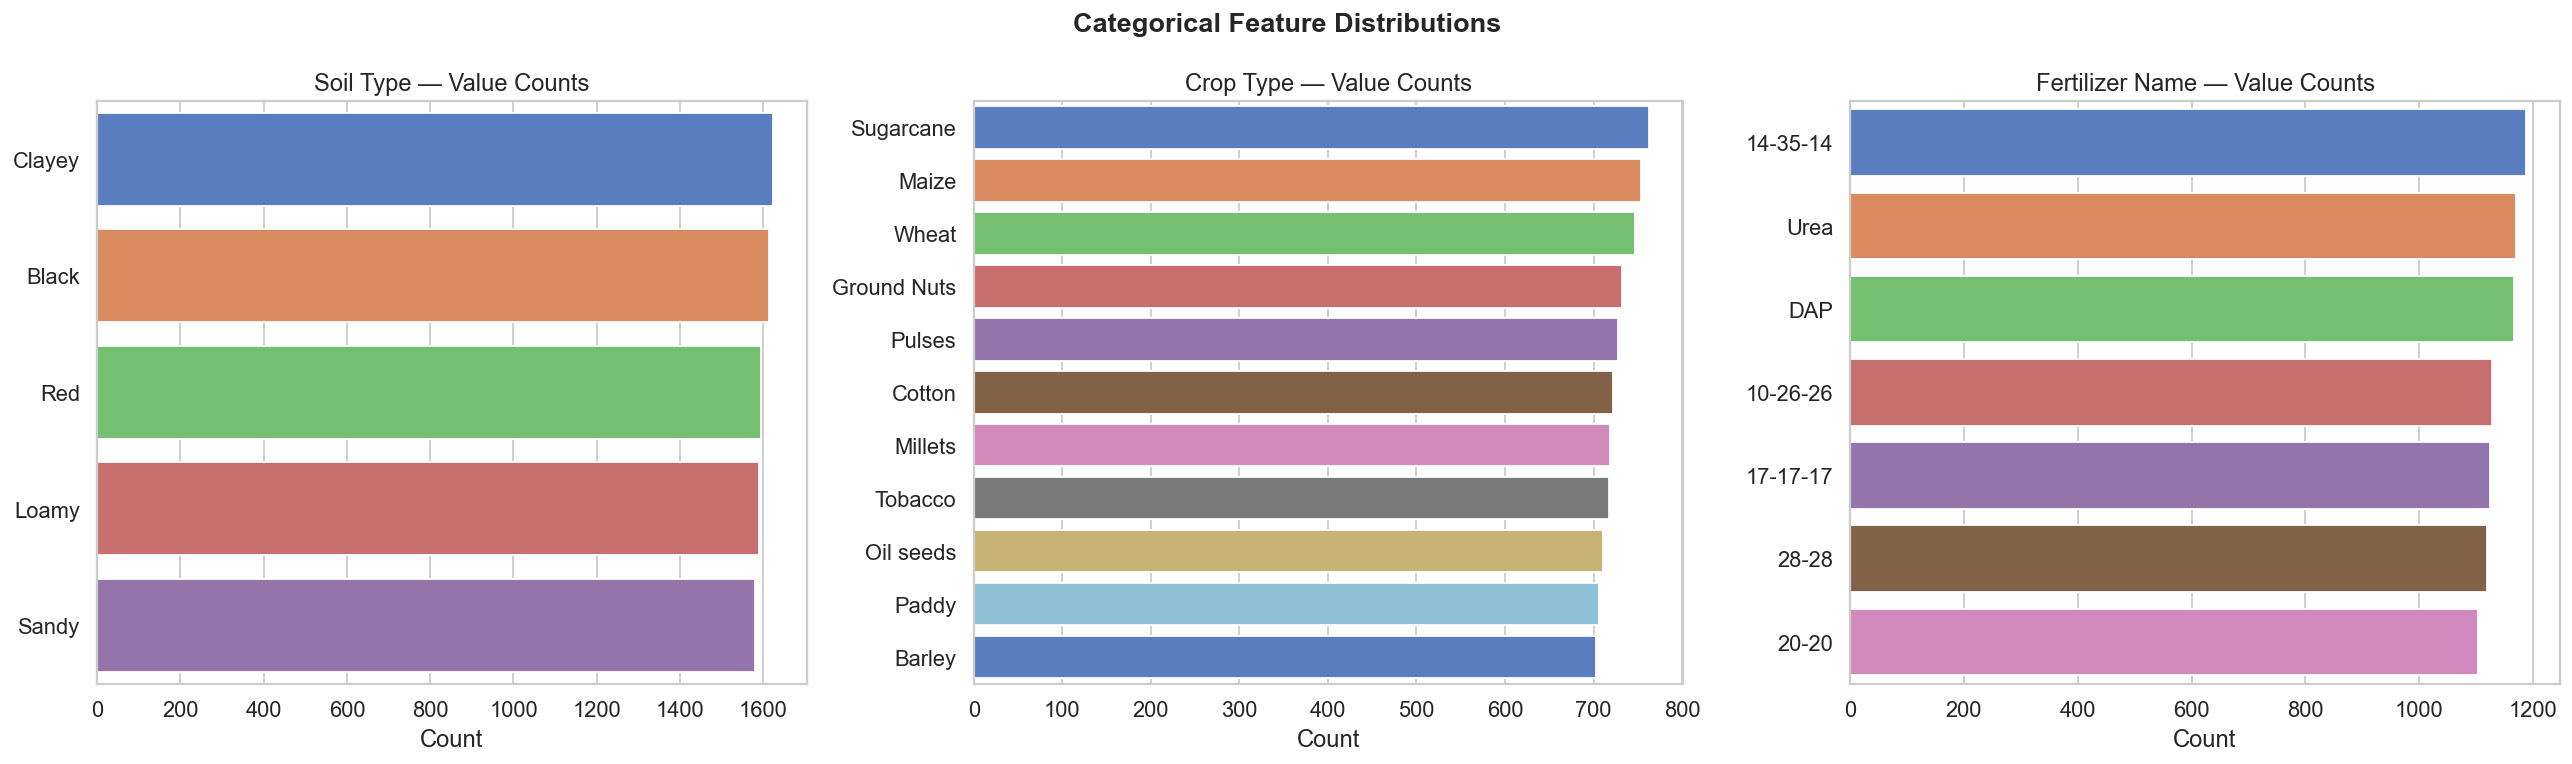

In [8]:
cat_cols = ["Soil Type", "Crop Type", "Fertilizer Name"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=axes[i], palette="muted")
    axes[i].set_title(f"{col} — Value Counts")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")

plt.suptitle("Categorical Feature Distributions", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/eda/04_categorical_distributions.png", bbox_inches="tight")
plt.show()


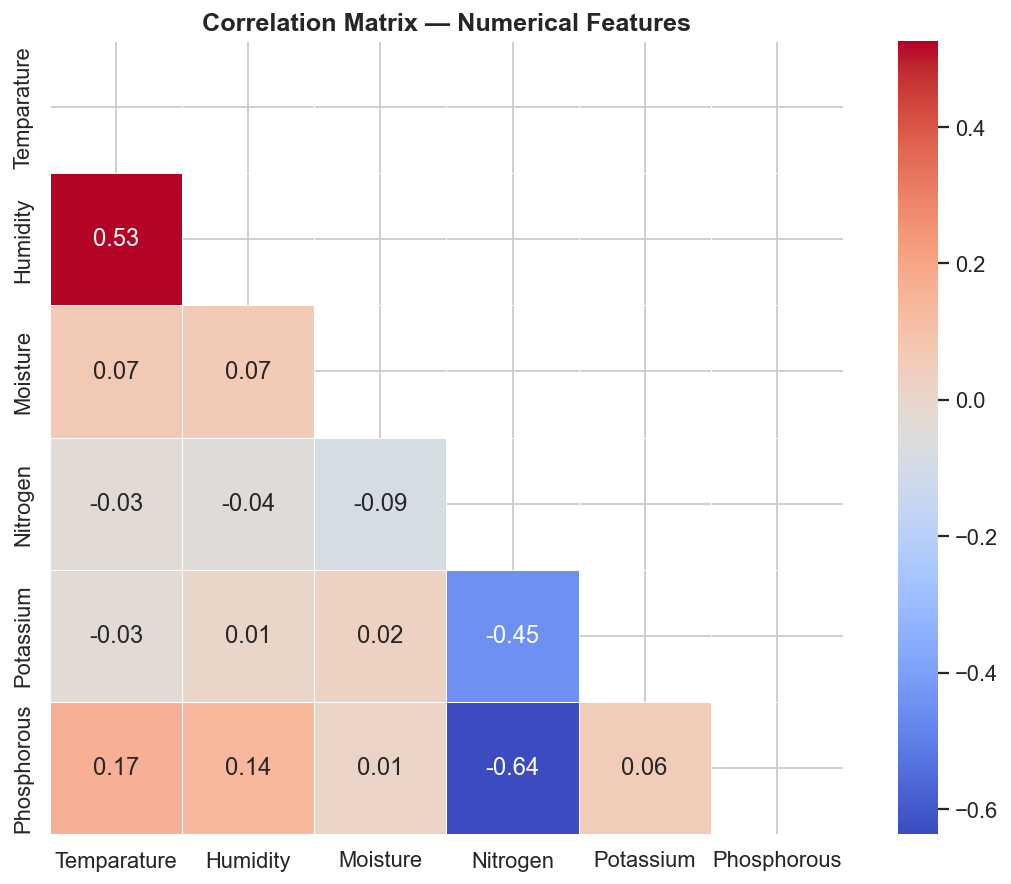

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, square=True)
ax.set_title("Correlation Matrix — Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/eda/05_correlation_heatmap.png", bbox_inches="tight")
plt.show()


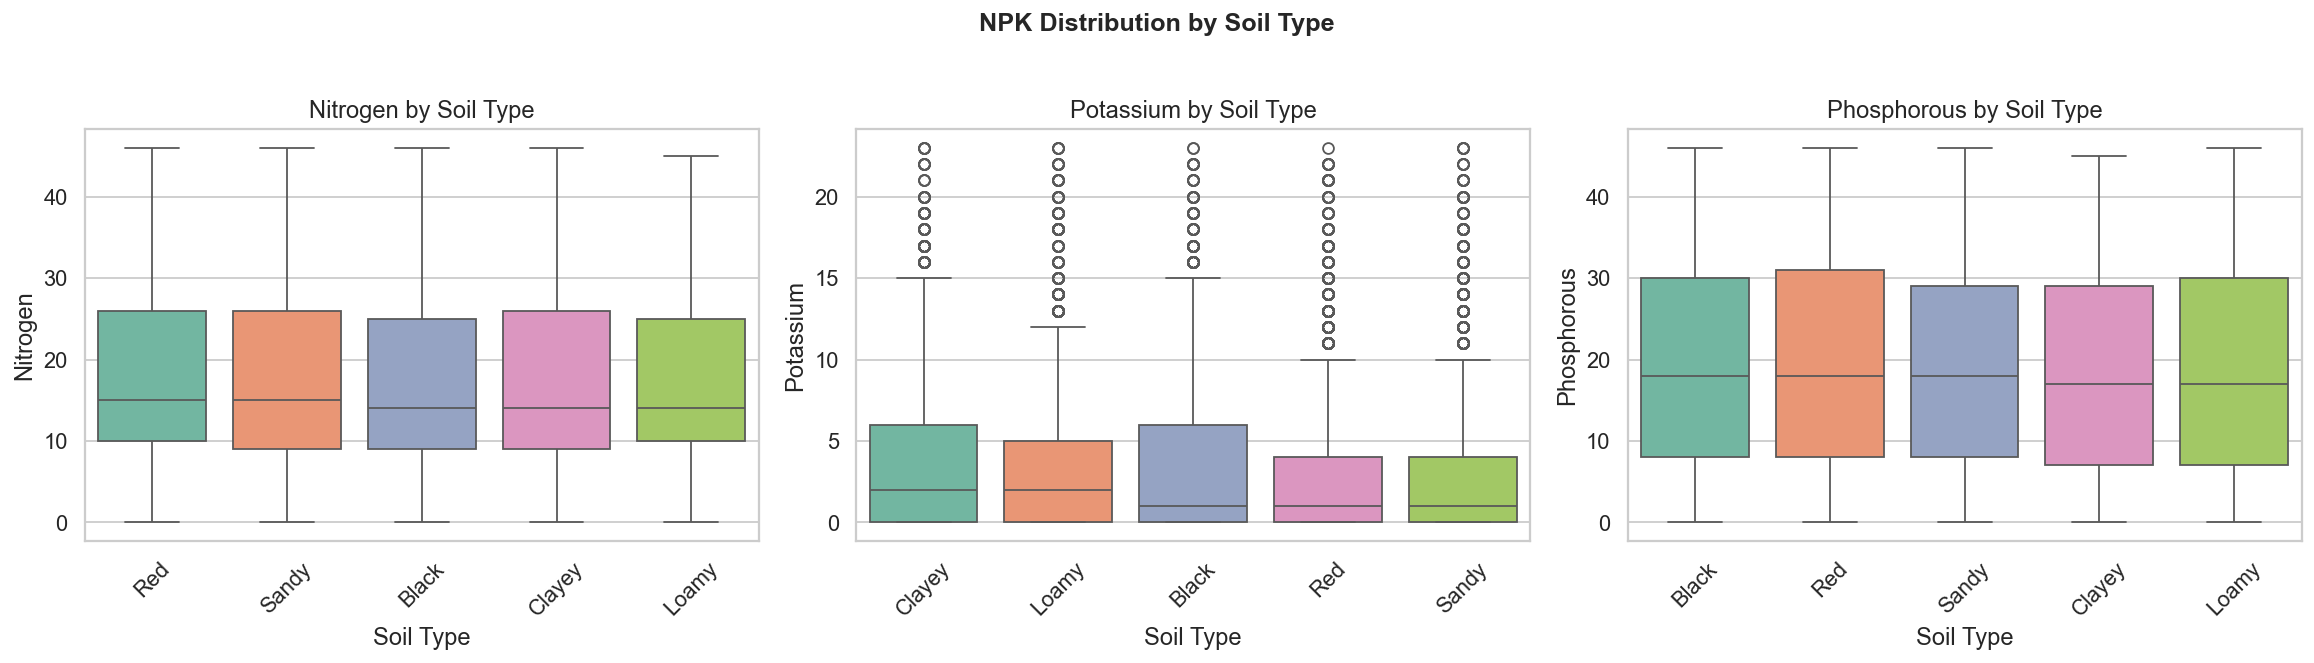

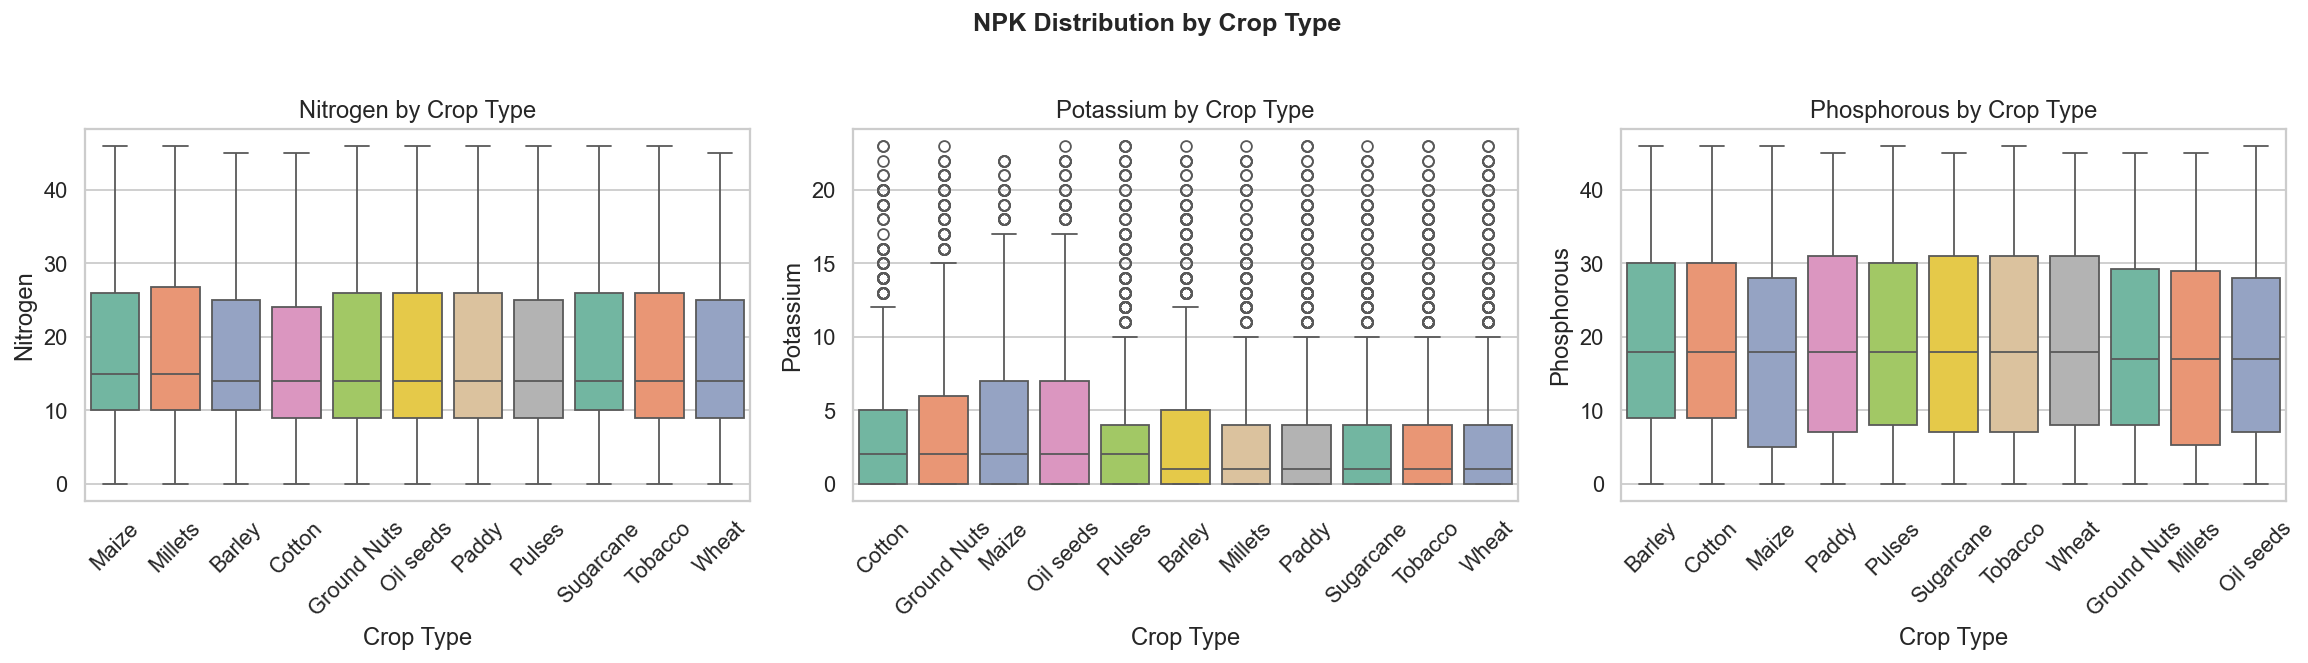

In [10]:
for target_col in ["Soil Type", "Crop Type"]:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, nutrient in enumerate(["Nitrogen", "Potassium", "Phosphorous"]):
        order = df.groupby(target_col)[nutrient].median().sort_values(ascending=False).index
        sns.boxplot(data=df, x=target_col, y=nutrient, ax=axes[i],
                    order=order, palette="Set2")
        axes[i].set_title(f"{nutrient} by {target_col}")
        axes[i].tick_params(axis="x", rotation=45)
    plt.suptitle(f"NPK Distribution by {target_col}", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    safe_name = target_col.lower().replace(" ", "_")
    plt.savefig(f"../visualizations/soil_prediction/eda/06_npk_by_{safe_name}.png", bbox_inches="tight")
    plt.show()


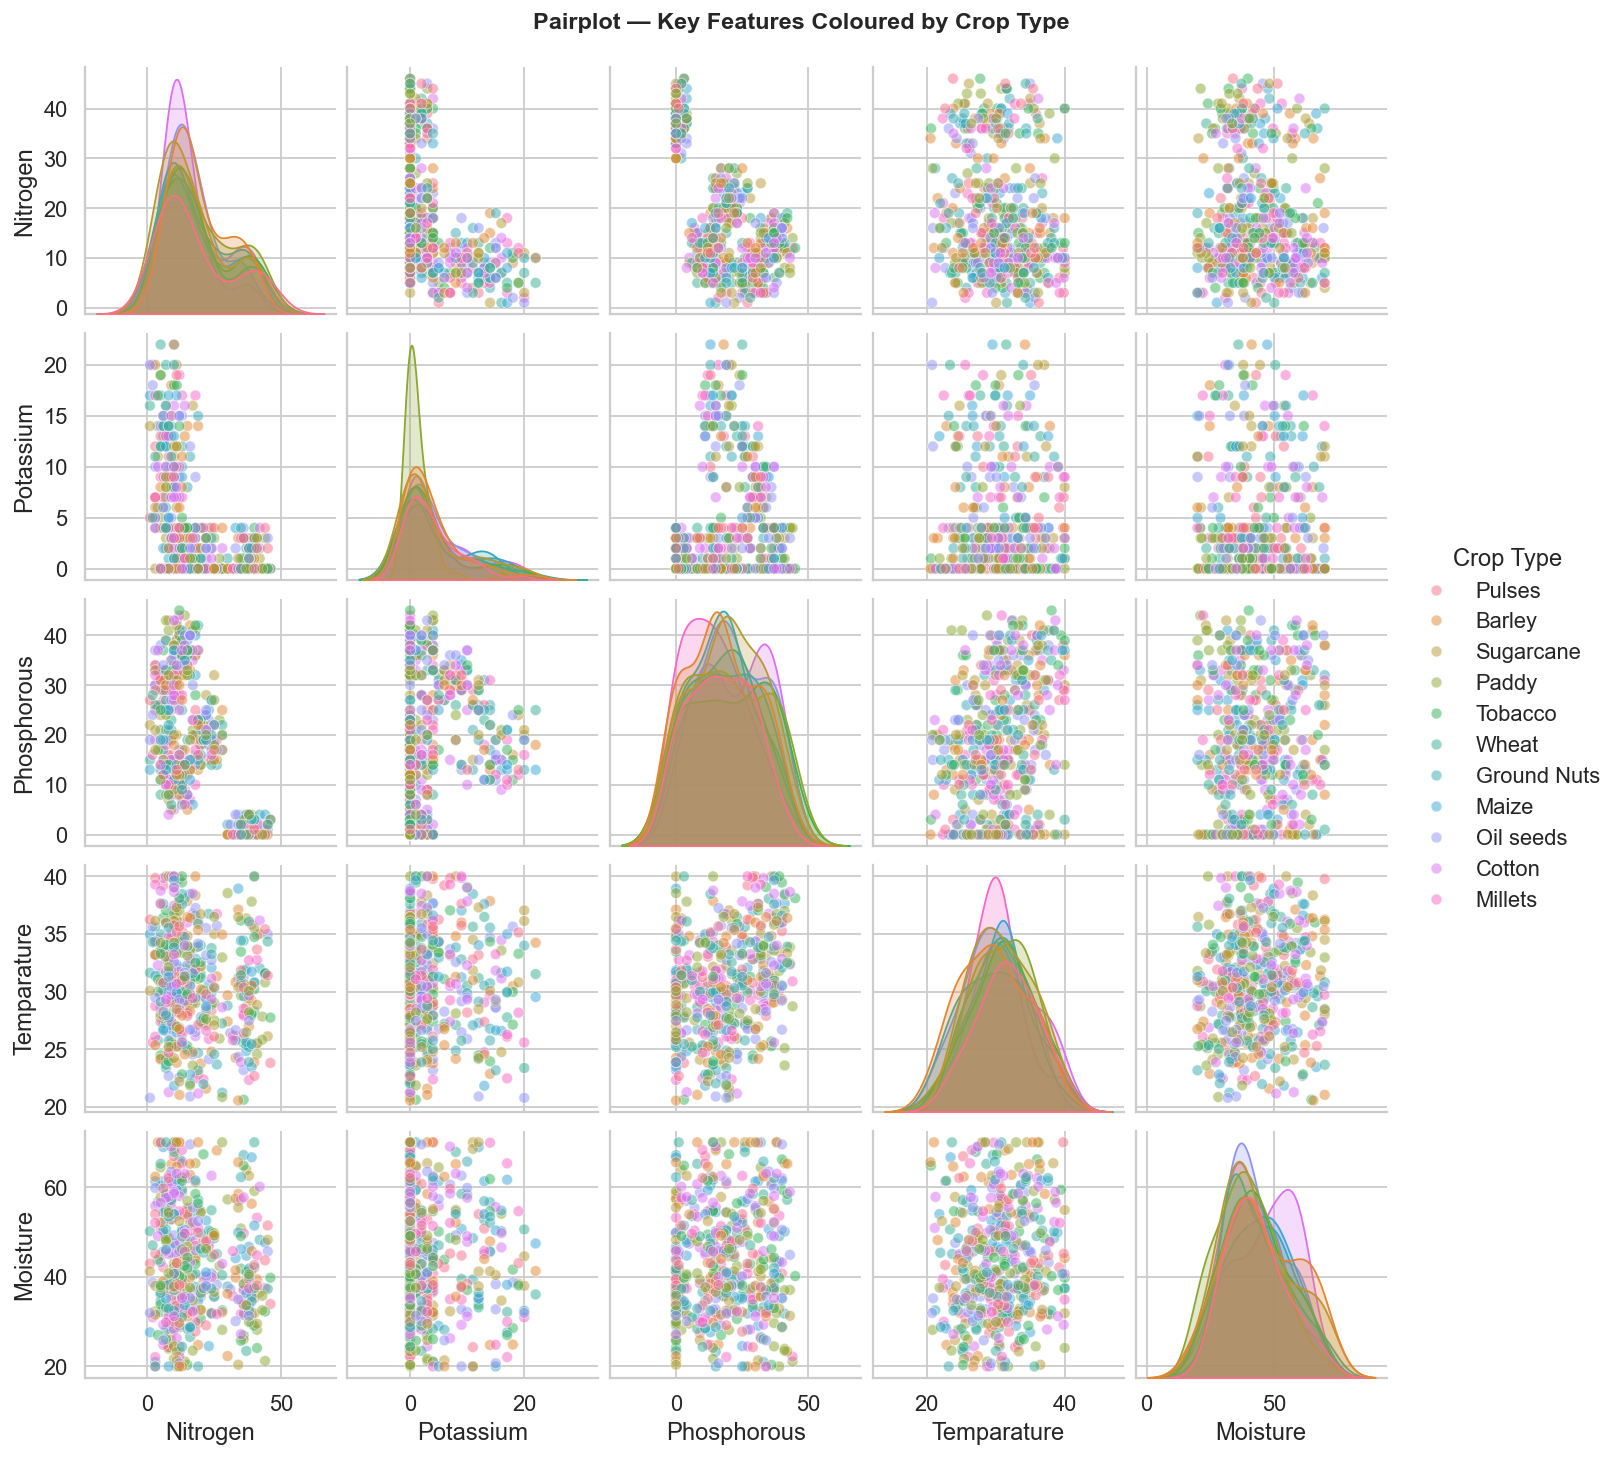

In [11]:
pair_df = df[["Nitrogen", "Potassium", "Phosphorous", "Temparature", "Moisture", "Crop Type"]].copy()
pair_df = pair_df.sample(500, random_state=42)

g = sns.pairplot(pair_df, hue="Crop Type", diag_kind="kde", plot_kws={"alpha": 0.5}, height=2.2)
g.fig.suptitle("Pairplot — Key Features Coloured by Crop Type", y=1.02, fontsize=13, fontweight="bold")
plt.savefig("../visualizations/soil_prediction/eda/07_pairplot.png", bbox_inches="tight")
plt.show()


# Feature Engineering & Shared Preprocessing

In [12]:
df_model = df.copy()

df_model["NPK_sum"]   = df_model["Nitrogen"] + df_model["Potassium"] + df_model["Phosphorous"]
df_model["N_P_ratio"] = df_model["Nitrogen"]   / (df_model["Phosphorous"] + 1)
df_model["N_K_ratio"] = df_model["Nitrogen"]   / (df_model["Potassium"]   + 1)

# Task 1 target: Soil Health Risk (rule-based from domain heuristics)
def soil_risk_label(row):
    n, p, k = row["Nitrogen"], row["Phosphorous"], row["Potassium"]
    deficient = sum([n < 20, p < 10, k < 10])
    if deficient >= 2:   return "High Risk"
    elif deficient == 1: return "Medium Risk"
    else:                return "Low Risk"

df_model["Soil_Risk"] = df_model.apply(soil_risk_label, axis=1)

# Task 4 target: Salinity Stress proxy (high Moisture + high Humidity)
moisture_thresh = df_model["Moisture"].quantile(0.80)
humidity_thresh = df_model["Humidity"].quantile(0.75)
df_model["Salinity_Stress"] = (
    (df_model["Moisture"] > moisture_thresh) &
    (df_model["Humidity"] > humidity_thresh)
).astype(int)

# Encode categoricals
le_soil = LabelEncoder()
le_crop = LabelEncoder()
le_fert = LabelEncoder()
df_model["Soil_Type_enc"] = le_soil.fit_transform(df_model["Soil Type"])
df_model["Crop_Type_enc"] = le_crop.fit_transform(df_model["Crop Type"])
df_model["Fert_Name_enc"] = le_fert.fit_transform(df_model["Fertilizer Name"])

print("New columns added:")
print([c for c in df_model.columns if c not in df.columns])
df_model.head(3)


New columns added:
['NPK_sum', 'N_P_ratio', 'N_K_ratio', 'Soil_Risk', 'Salinity_Stress', 'Soil_Type_enc', 'Crop_Type_enc', 'Fert_Name_enc']


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name,NPK_sum,N_P_ratio,N_K_ratio,Soil_Risk,Salinity_Stress,Soil_Type_enc,Crop_Type_enc,Fert_Name_enc
0,26.0,52.0,38.0,Sandy,Maize,37,0,0,Urea,37,37.000000,37.0,High Risk,0,4,3,6
1,29.0,52.0,45.0,Loamy,Sugarcane,12,0,36,DAP,48,0.324324,12.0,High Risk,0,2,8,5
2,34.0,65.0,62.0,Black,Cotton,7,9,30,14-35-14,46,0.225806,0.7,High Risk,0,0,1,1


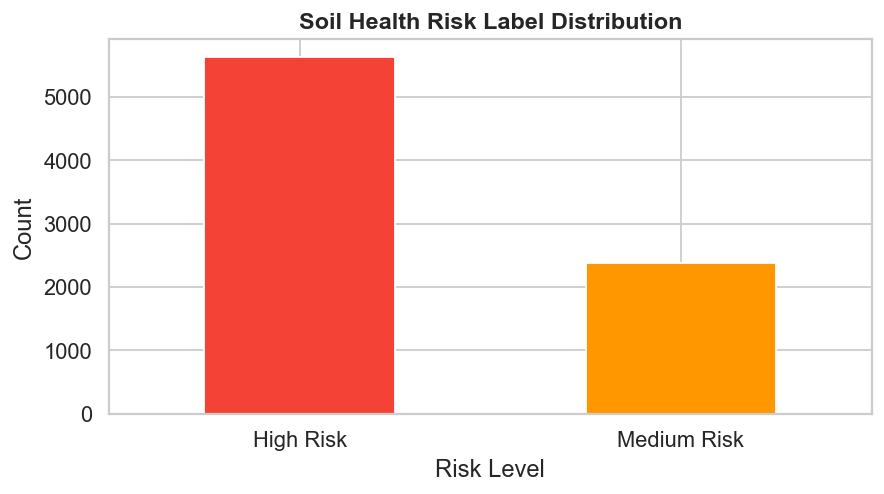

Soil_Risk
High Risk      5629
Medium Risk    2371
Name: count, dtype: int64


In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
risk_counts = df_model["Soil_Risk"].value_counts()
colors = {"Low Risk": "#4CAF50", "Medium Risk": "#FF9800", "High Risk": "#F44336"}
risk_counts.plot(kind="bar", color=[colors[k] for k in risk_counts.index], ax=ax, edgecolor="white")
ax.set_title("Soil Health Risk Label Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Risk Level")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/eda/08_soil_risk_distribution.png", bbox_inches="tight")
plt.show()
print(risk_counts)


In [14]:
def compare_classifiers(X_train, X_test, y_train, y_test, task_name, label_names=None):
    """Train multiple classifiers, plot comparison + confusion matrix, return results."""
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Decision Tree":       DecisionTreeClassifier(random_state=42),
        "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
        "SVM":                 SVC(probability=True, random_state=42),
        "KNN":                 KNeighborsClassifier(n_neighbors=7),
        "Gradient Boosting":   GradientBoostingClassifier(n_estimators=150, random_state=42),
        "XGBoost":             XGBClassifier(n_estimators=150, use_label_encoder=False,
                                             eval_metric="mlogloss", random_state=42, verbosity=0),
        "LightGBM":            LGBMClassifier(n_estimators=150, random_state=42, verbosity=-1),
    }
    results, trained = {}, {}
    for name, clf in models.items():
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        results[name] = {
            "Accuracy":   accuracy_score(y_test, y_pred),
            "F1 (macro)": f1_score(y_test, y_pred, average="macro"),
        }
        trained[name] = pipe
        print(f"  {name:25s}  Acc={results[name]['Accuracy']:.4f}  F1={results[name]['F1 (macro)']:.4f}")

    df_res = pd.DataFrame(results).T.sort_values("Accuracy", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax_i, metric in enumerate(["Accuracy", "F1 (macro)"]):
        df_res[metric].sort_values().plot(kind="barh", ax=axes[ax_i], color="#4A90D9", edgecolor="white")
        axes[ax_i].set_xlim(0, 1)
        axes[ax_i].set_title(f"{metric} — {task_name}", fontweight="bold")
        axes[ax_i].axvline(df_res[metric].max(), color="red", linestyle="--", lw=1, label="Best")
        axes[ax_i].legend()
    plt.tight_layout()
    safe = task_name.lower().replace(" ", "_")
    plt.savefig(f"../visualizations/soil_prediction/models/{safe}_comparison.png", bbox_inches="tight")
    plt.show()

    best_name = df_res["Accuracy"].idxmax()
    y_pred_best = trained[best_name].predict(X_test)
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, display_labels=label_names,
                                            ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {best_name} ({task_name})", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"../visualizations/soil_prediction/models/{safe}_confusion_matrix.png", bbox_inches="tight")
    plt.show()

    print(f"\nBest model: {best_name}")
    return df_res, trained, best_name


def compare_regressors(X_train, X_test, y_train, y_test, task_name):
    """Train multiple regressors, plot comparison + scatter, return results."""
    models = {
        "Ridge Regression":  Ridge(alpha=1.0),
        "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=42),
        "SVR":               SVR(kernel="rbf"),
        "XGBoost":           XGBRegressor(n_estimators=150, random_state=42, verbosity=0),
        "LightGBM":          LGBMRegressor(n_estimators=150, random_state=42, verbosity=-1),
    }
    results, trained = {}, {}
    for name, reg in models.items():
        pipe = Pipeline([("scaler", StandardScaler()), ("reg", reg)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        results[name] = {
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "R²":   r2_score(y_test, y_pred),
        }
        trained[name] = pipe
        print(f"  {name:22s}  RMSE={results[name]['RMSE']:.3f}  R²={results[name]['R²']:.4f}")

    df_res = pd.DataFrame(results).T.sort_values("R²", ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    df_res["RMSE"].sort_values(ascending=False).plot(kind="barh", ax=axes[0], color="#E07B54", edgecolor="white")
    axes[0].set_title(f"RMSE — {task_name}", fontweight="bold")
    df_res["R²"].sort_values().plot(kind="barh", ax=axes[1], color="#5BAD6F", edgecolor="white")
    axes[1].set_title(f"R² Score — {task_name}", fontweight="bold")
    plt.tight_layout()
    safe = task_name.lower().replace(" ", "_")
    plt.savefig(f"../visualizations/soil_prediction/models/{safe}_comparison.png", bbox_inches="tight")
    plt.show()

    best_name = df_res["R²"].idxmax()
    print(f"\nBest model: {best_name}")
    return df_res, trained, best_name


# Task 1: Soil Health Risk Classification

TASK 1 — Soil Health & Degradation Risk Classification
  Logistic Regression        Acc=0.9475  F1=0.9363
  Decision Tree              Acc=1.0000  F1=1.0000
  Random Forest              Acc=1.0000  F1=1.0000
  SVM                        Acc=0.9669  F1=0.9607
  KNN                        Acc=0.9513  F1=0.9424
  Gradient Boosting          Acc=1.0000  F1=1.0000
  XGBoost                    Acc=1.0000  F1=1.0000
  LightGBM                   Acc=1.0000  F1=1.0000


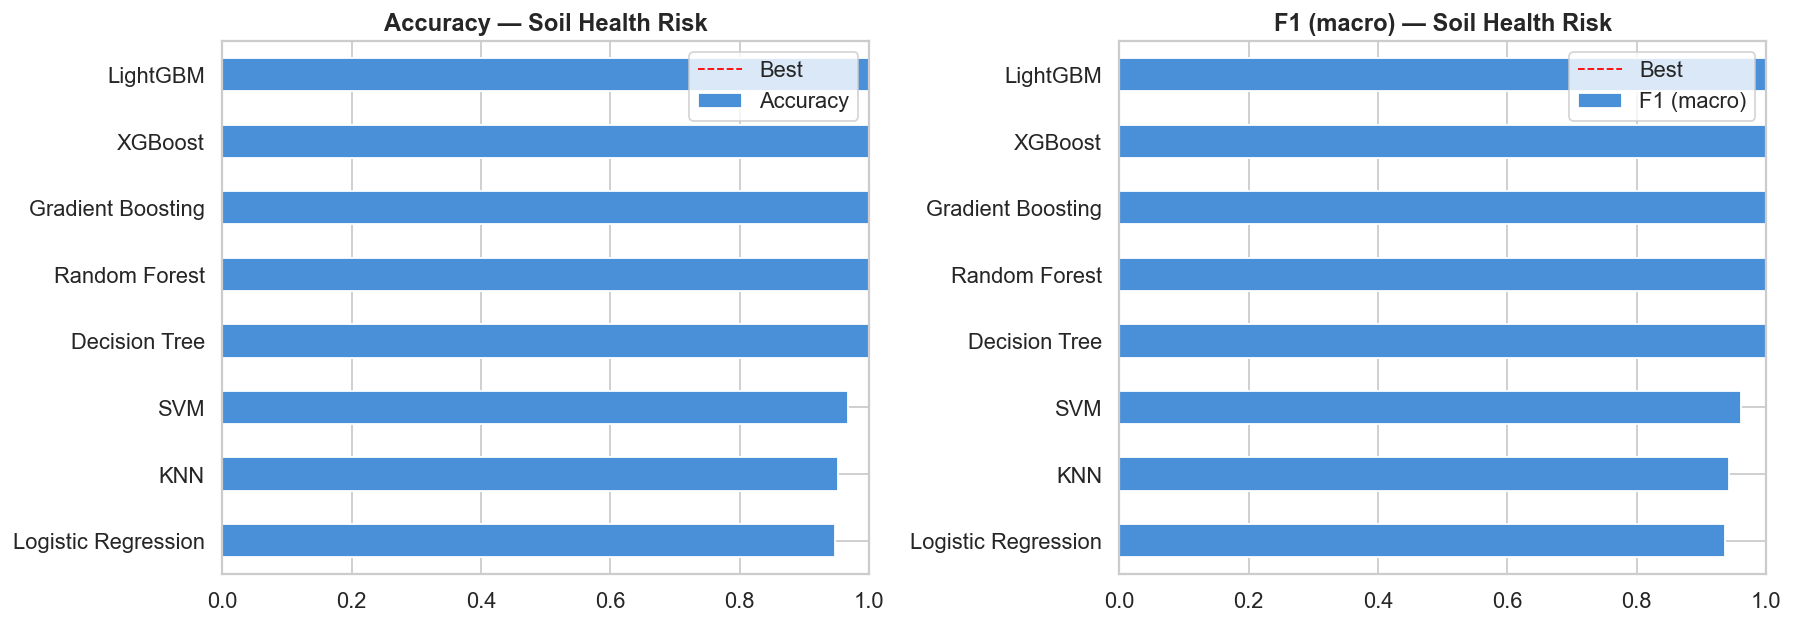

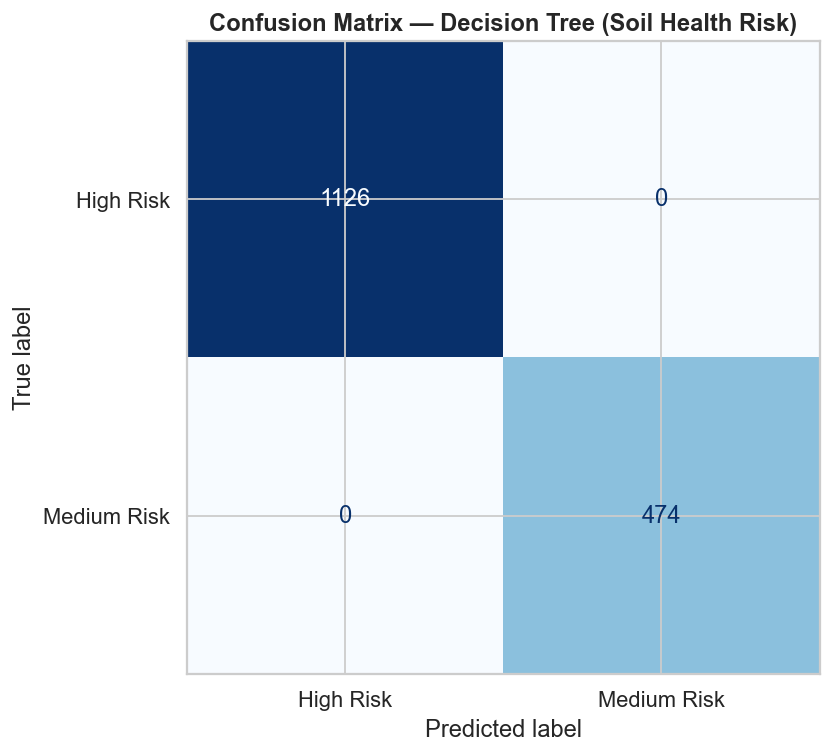


Best model: Decision Tree


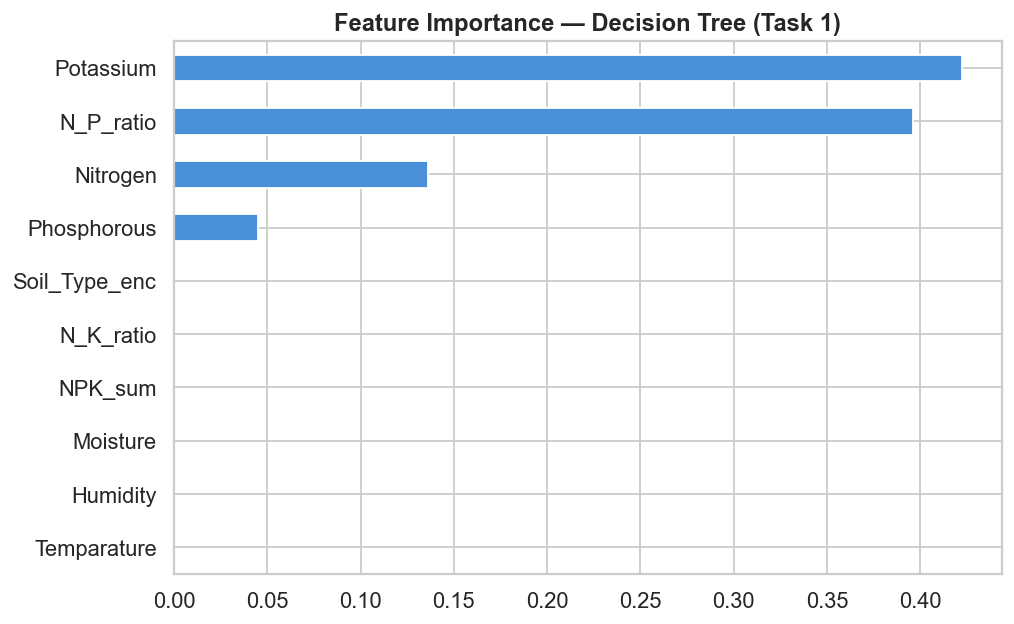

5-fold CV Accuracy: 1.0000 ± 0.0000

Classification Report (Decision Tree):
              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00      1126
 Medium Risk       1.00      1.00      1.00       474

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600

Saved: task1_soil_risk_best.pkl  (Decision Tree)


,Accuracy,F1 (macro)
Decision Tree,1.000000,1.000000
Random Forest,1.000000,1.000000
Gradient Boosting,1.000000,1.000000
XGBoost,1.000000,1.000000
LightGBM,1.000000,1.000000
SVM,0.966875,0.960682
KNN,0.951250,0.942372
Logistic Regression,0.947500,0.936337


In [15]:
print("=" * 60)
print("TASK 1 — Soil Health & Degradation Risk Classification")
print("=" * 60)

features_t1 = ["Nitrogen", "Potassium", "Phosphorous",
                "Temparature", "Humidity", "Moisture",
                "NPK_sum", "N_P_ratio", "N_K_ratio", "Soil_Type_enc"]

le_risk = LabelEncoder()
X_t1 = df_model[features_t1]
y_t1 = le_risk.fit_transform(df_model["Soil_Risk"])

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_t1, y_t1, test_size=0.2, stratify=y_t1, random_state=42)

results_t1, trained_t1, best_t1 = compare_classifiers(
    X_train1, X_test1, y_train1, y_test1,
    task_name="Soil Health Risk", label_names=le_risk.classes_)

best_pipe_t1 = trained_t1[best_t1]

# Feature importance
if hasattr(best_pipe_t1["clf"], "feature_importances_"):
    feat_df = pd.Series(best_pipe_t1["clf"].feature_importances_,
                        index=features_t1).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    feat_df.plot(kind="barh", ax=ax, color="#4A90D9", edgecolor="white")
    ax.set_title(f"Feature Importance — {best_t1} (Task 1)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("../visualizations/soil_prediction/models/task1_feature_importance.png", bbox_inches="tight")
    plt.show()

# 5-fold CV
cv_scores = cross_val_score(best_pipe_t1, X_t1, y_t1, cv=5, scoring="accuracy")
print(f"5-fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print(f"\nClassification Report ({best_t1}):")
print(classification_report(y_test1, best_pipe_t1.predict(X_test1), target_names=le_risk.classes_))

joblib.dump(best_pipe_t1, "../models/soil_prediction/task1_soil_risk_best.pkl")
joblib.dump(le_risk,      "../models/soil_prediction/task1_label_encoder_risk.pkl")
print(f"Saved: task1_soil_risk_best.pkl  ({best_t1})")
results_t1


# Task 2: Optimal Crop Recommendation

TASK 2 — DIAGNOSIS: Primary dataset has no crop signal
Overall NPK variance:
Nitrogen       140.48
Potassium       30.19
Phosphorous    175.41
dtype: float64

Mean within-crop NPK variance:
Nitrogen       140.49
Potassium       30.19
Phosphorous    175.40
dtype: float64

→ If within ≈ overall, crops are inseparable in this feature space.

Entropy of Crop Type per Fertilizer (max entropy = uniform):
  10-26-26        entropy=2.391  (max=2.398)
  14-35-14        entropy=2.394  (max=2.398)
  17-17-17        entropy=2.393  (max=2.398)
  20-20           entropy=2.394  (max=2.398)
  28-28           entropy=2.397  (max=2.398)
  DAP             entropy=2.393  (max=2.398)
  Urea            entropy=2.397  (max=2.398)


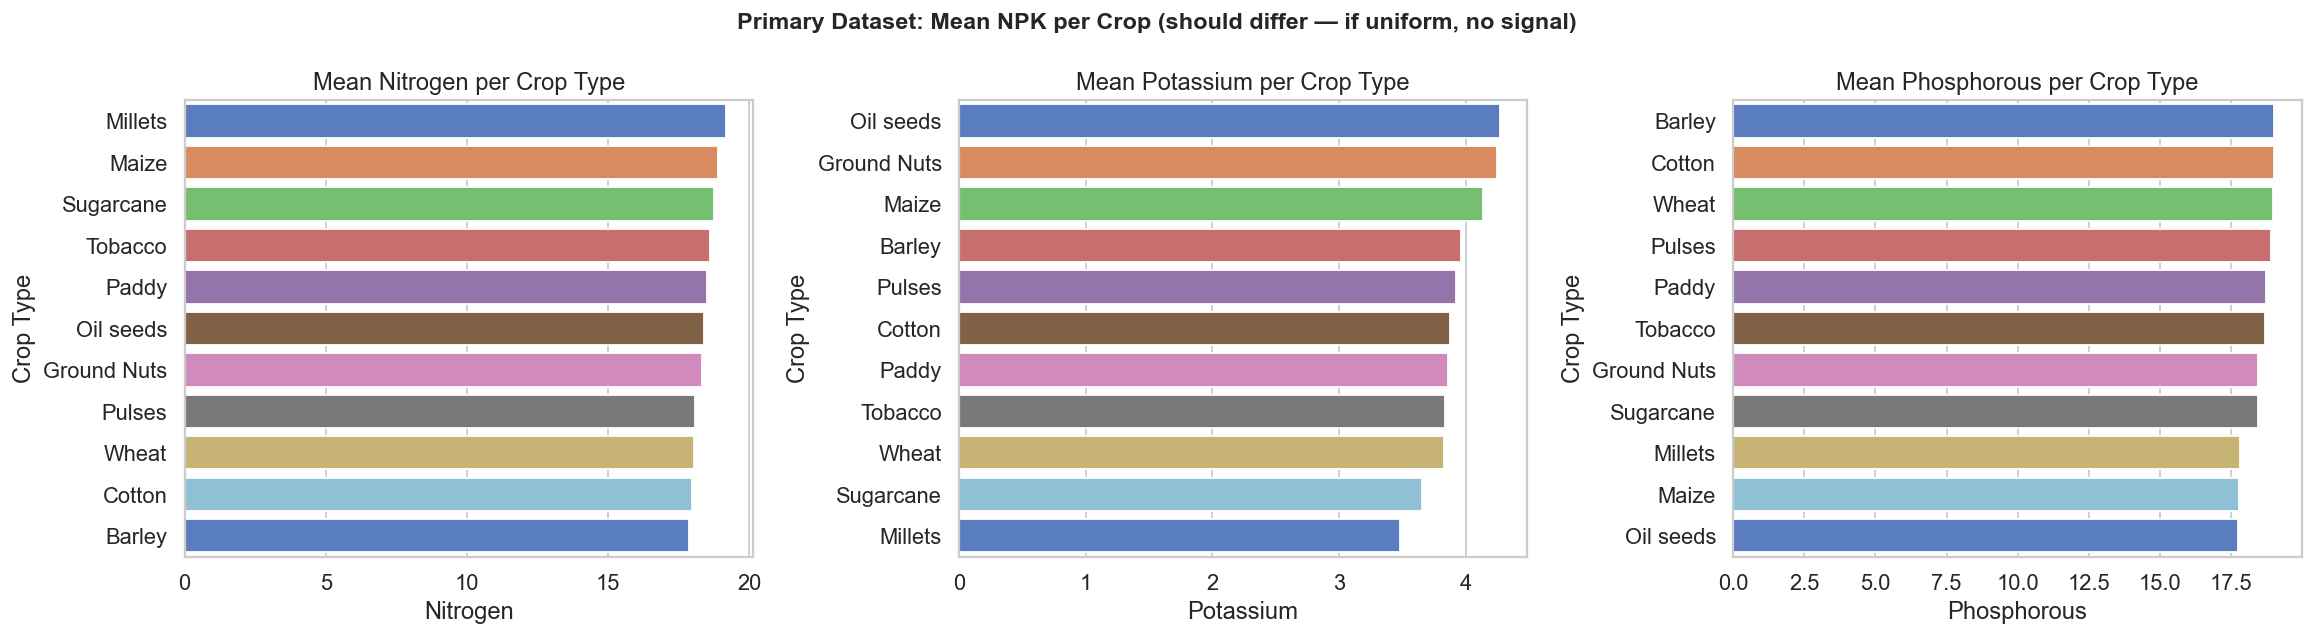


→ Conclusion: primary dataset is synthetically uniform — switching to real crop dataset.


In [16]:
print("=" * 60)
print("TASK 2 — DIAGNOSIS: Primary dataset has no crop signal")
print("=" * 60)

# NPK variance: within-crop vs overall
overall_var = df_model[["Nitrogen", "Potassium", "Phosphorous"]].var()
within_var  = df_model.groupby("Crop Type")[["Nitrogen", "Potassium", "Phosphorous"]].var().mean()
print("Overall NPK variance:")
print(overall_var.round(2))
print("\nMean within-crop NPK variance:")
print(within_var.round(2))
print("\n→ If within ≈ overall, crops are inseparable in this feature space.")

# Entropy of crop label conditional on fertilizer
print("\nEntropy of Crop Type per Fertilizer (max entropy = uniform):")
ct_norm = pd.crosstab(df_model["Fertilizer Name"], df_model["Crop Type"], normalize="index")
for fert in ct_norm.index:
    ent = entropy(ct_norm.loc[fert])
    print(f"  {fert:14s}  entropy={ent:.3f}  (max={np.log(df_model['Crop Type'].nunique()):.3f})")

# Visualise: mean NPK per crop — should differ if there's signal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, nutrient in enumerate(["Nitrogen", "Potassium", "Phosphorous"]):
    means = df_model.groupby("Crop Type")[nutrient].mean().sort_values(ascending=False)
    sns.barplot(x=means.values, y=means.index, ax=axes[i], palette="muted")
    axes[i].set_title(f"Mean {nutrient} per Crop Type")
    axes[i].set_xlabel(nutrient)
plt.suptitle("Primary Dataset: Mean NPK per Crop (should differ — if uniform, no signal)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/eda/task2_diagnosis_npk_per_crop.png", bbox_inches="tight")
plt.show()
print("\n→ Conclusion: primary dataset is synthetically uniform — switching to real crop dataset.")


In [17]:
path_crop = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")
print("Path:", path_crop)
print("Files:", os.listdir(path_crop))

df_crop = pd.read_csv(os.path.join(path_crop, "Crop_recommendation.csv"))
print(f"\nShape: {df_crop.shape}")
print(f"Columns: {df_crop.columns.tolist()}")
print(f"\nCrop classes ({df_crop['label'].nunique()}):")
print(df_crop["label"].value_counts())
df_crop.describe()


Path: /Users/macbook/.cache/kagglehub/datasets/atharvaingle/crop-recommendation-dataset/versions/1
Files: ['Crop_recommendation.csv']

Shape: (2200, 8)
Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Crop classes (22):
label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


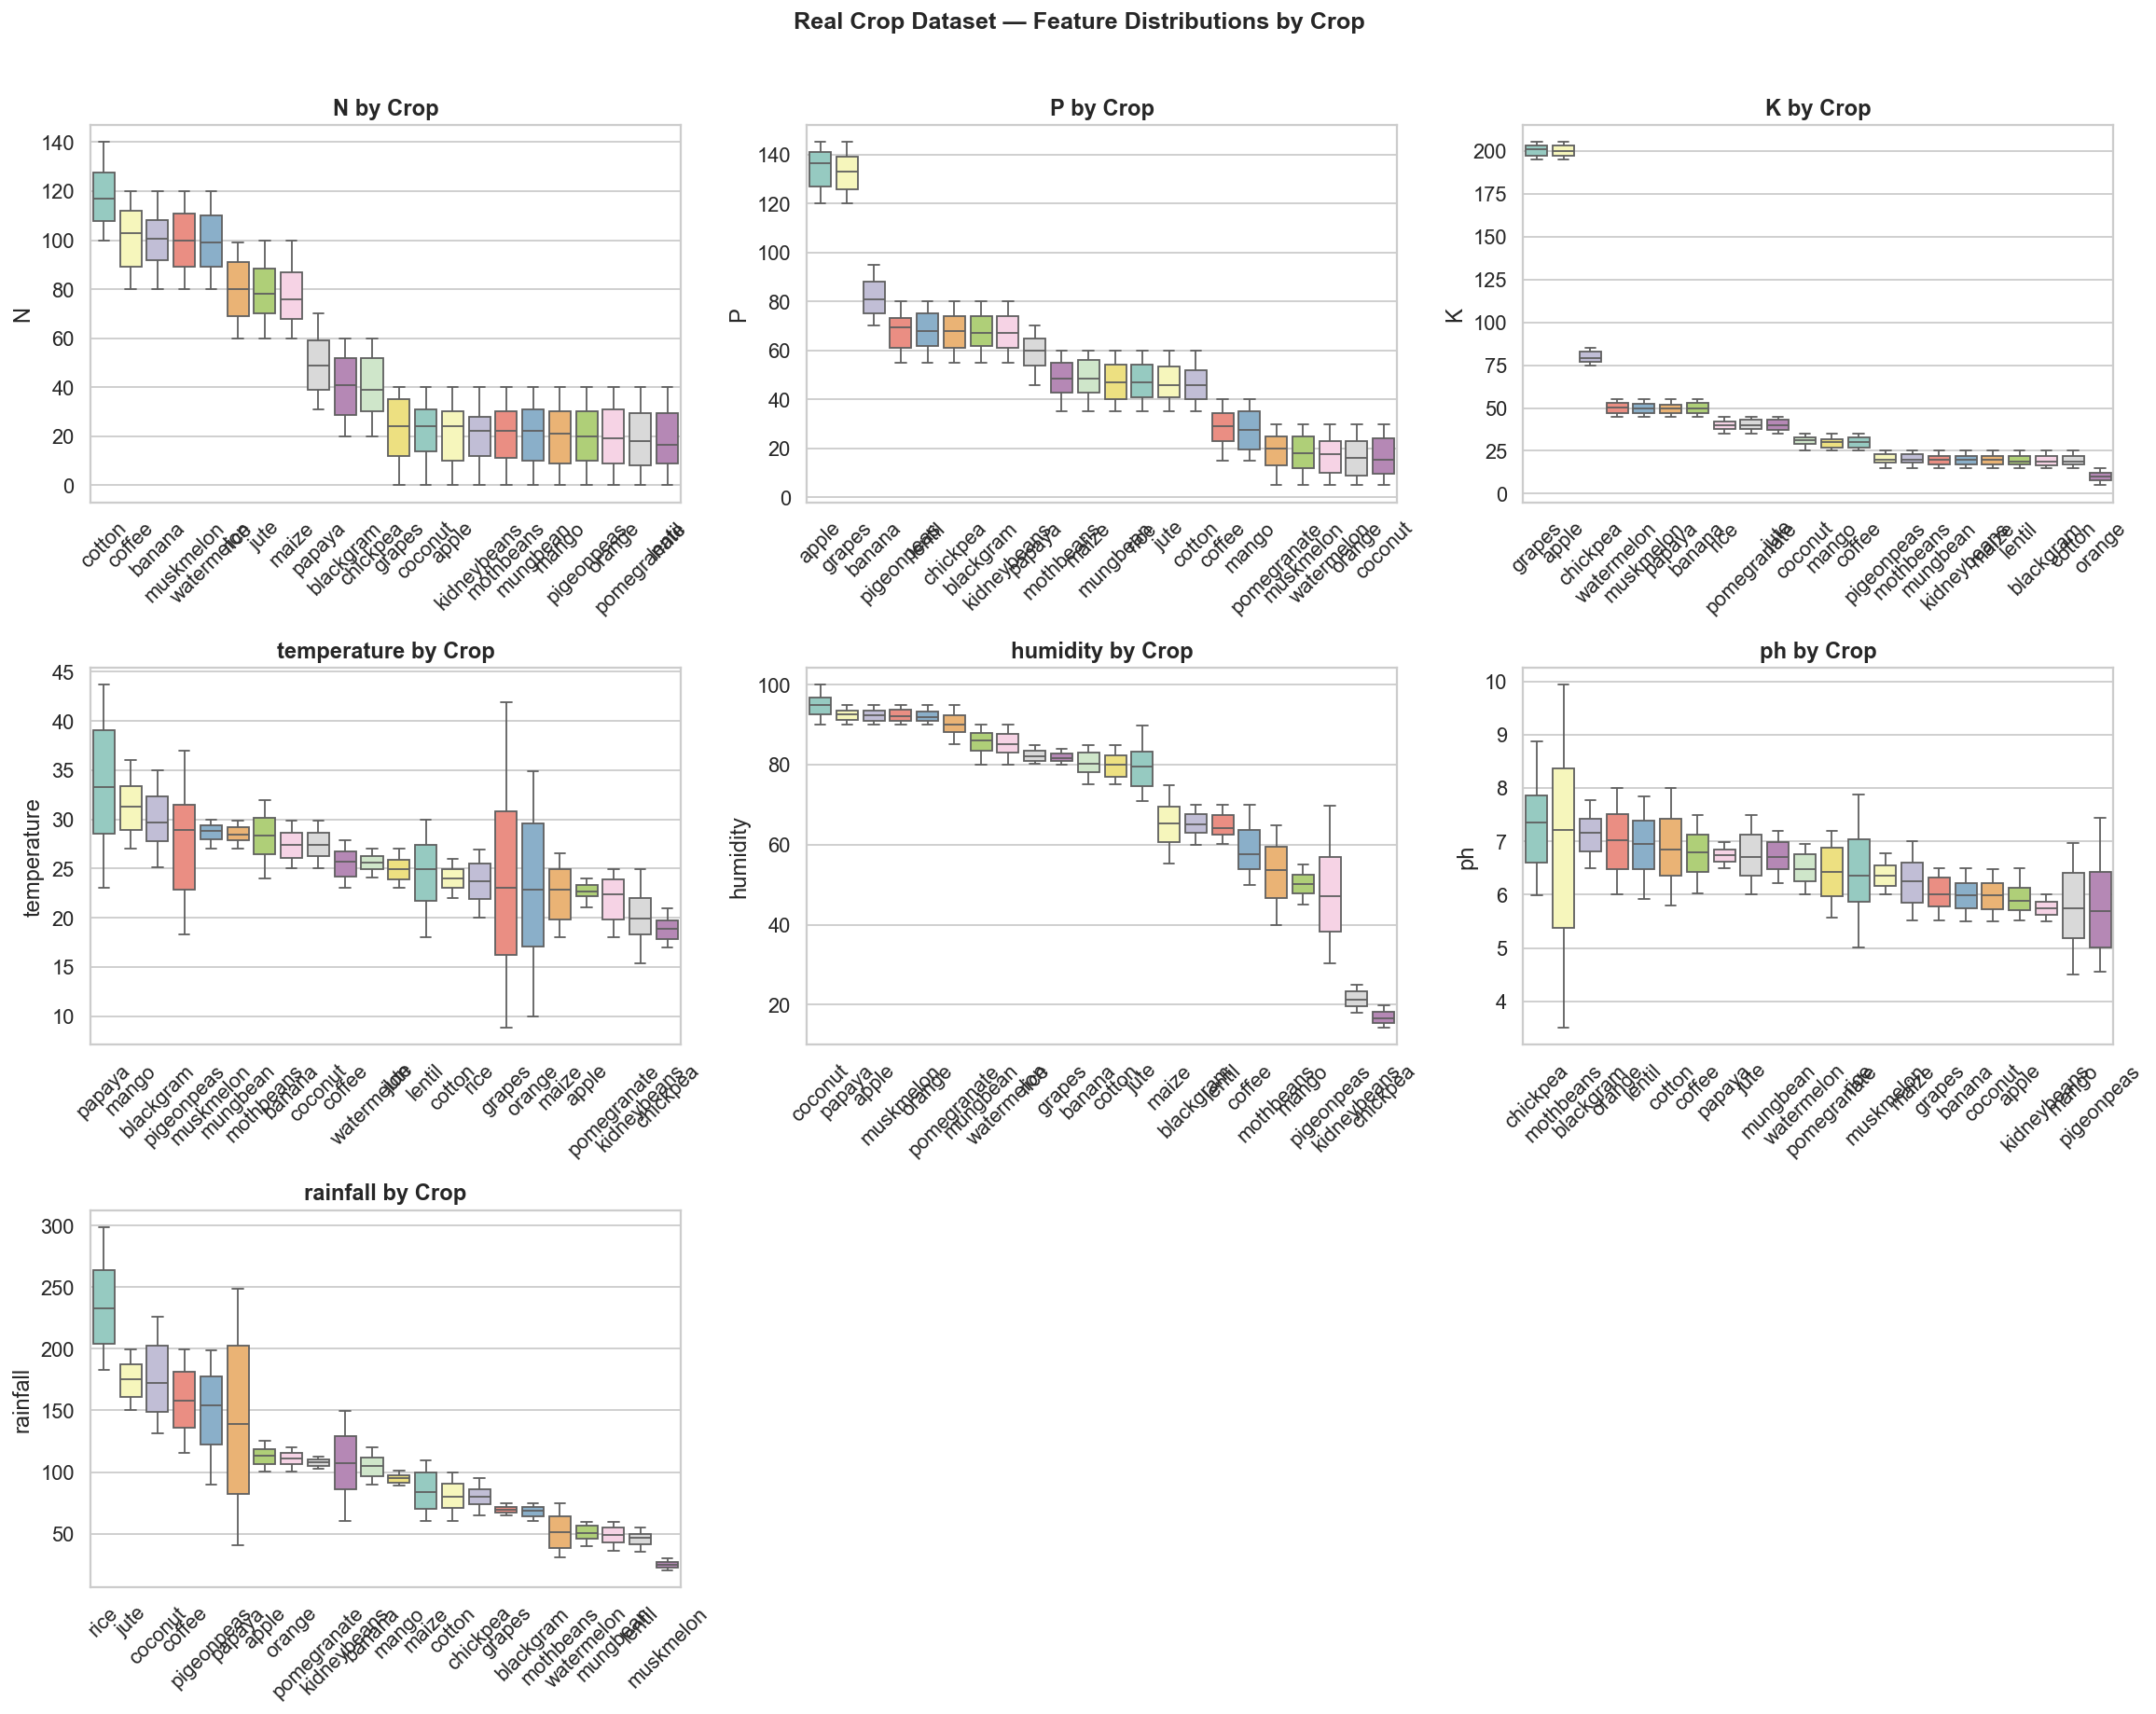

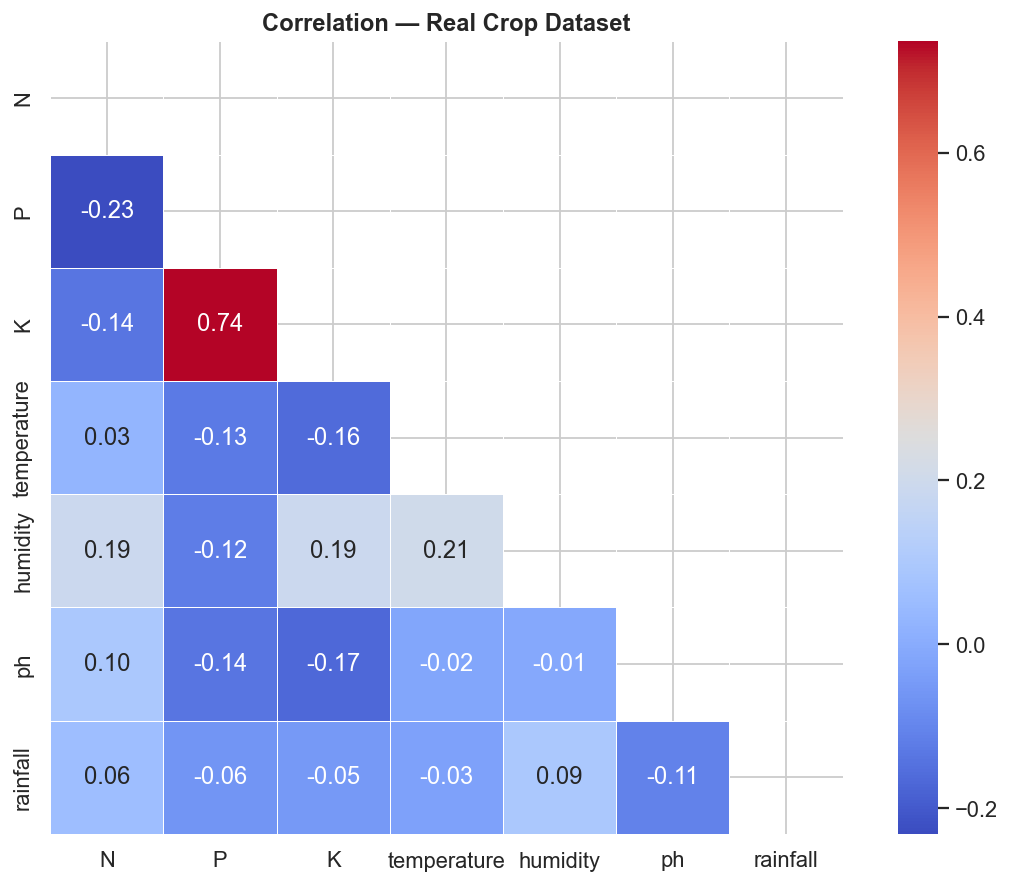

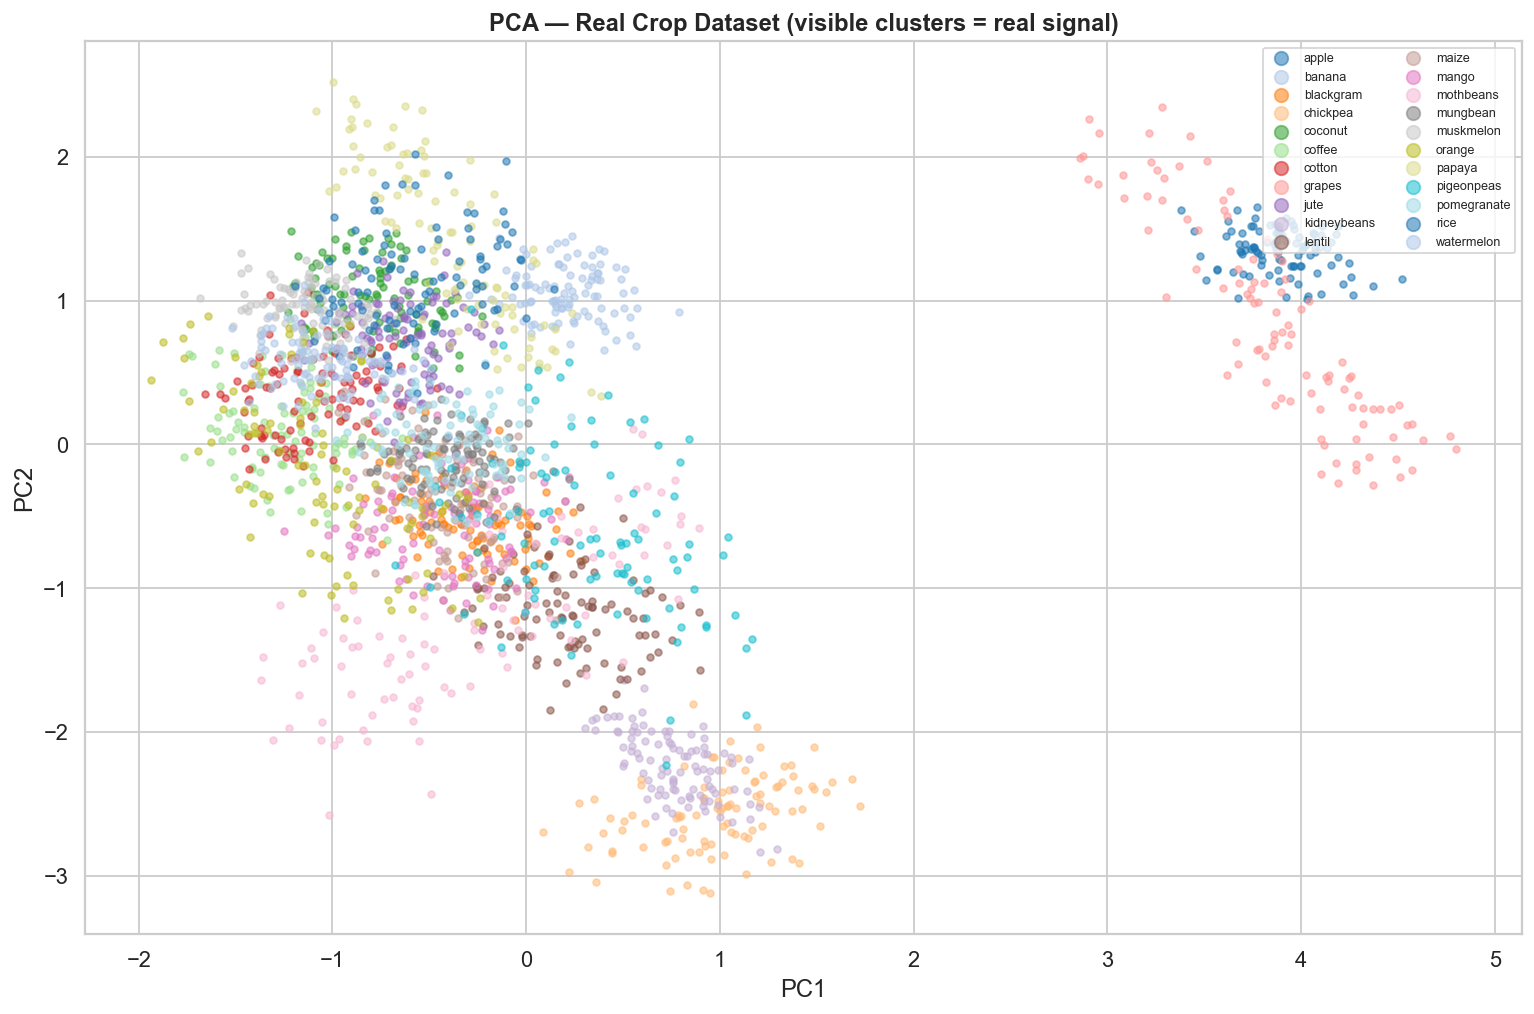

In [18]:
num_cols_crop = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

# Feature distributions per crop
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols_crop):
    order = df_crop.groupby("label")[col].median().sort_values(ascending=False).index
    sns.boxplot(data=df_crop, x="label", y=col, ax=axes[i], order=order, palette="Set3")
    axes[i].set_title(f"{col} by Crop", fontweight="bold")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].set_xlabel("")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Real Crop Dataset — Feature Distributions by Crop", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/eda/09_crop_real_distributions.png", bbox_inches="tight")
plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))
corr_crop = df_crop[num_cols_crop].corr()
sns.heatmap(corr_crop, annot=True, fmt=".2f", cmap="coolwarm",
            mask=np.triu(np.ones_like(corr_crop, dtype=bool)),
            ax=ax, square=True, linewidths=0.5)
ax.set_title("Correlation — Real Crop Dataset", fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/eda/10_crop_real_correlation.png", bbox_inches="tight")
plt.show()

# PCA separability
le_crop_real  = LabelEncoder()
y_crop_real   = le_crop_real.fit_transform(df_crop["label"])
X_crop_scaled = StandardScaler().fit_transform(df_crop[num_cols_crop])
X_pca2d       = PCA(n_components=2, random_state=42).fit_transform(X_crop_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
palette_pca = sns.color_palette("tab20", n_colors=df_crop["label"].nunique())
for i, crop in enumerate(le_crop_real.classes_):
    mask = df_crop["label"] == crop
    ax.scatter(X_pca2d[mask, 0], X_pca2d[mask, 1],
               label=crop, alpha=0.55, s=14, color=palette_pca[i])
ax.set_title("PCA — Real Crop Dataset (visible clusters = real signal)", fontweight="bold")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(loc="upper right", fontsize=7, markerscale=2, ncol=2)
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/eda/11_crop_real_pca.png", bbox_inches="tight")
plt.show()


TASK 2 — Baseline: All Models on Real Crop Dataset
Train: (1760, 13)  Test: (440, 13)  Classes: 22

  Logistic Regression        Acc=0.9773  F1=0.9772
  Decision Tree              Acc=0.9773  F1=0.9774
  Random Forest              Acc=0.9955  F1=0.9955
  SVM                        Acc=0.9795  F1=0.9794
  KNN                        Acc=0.9636  F1=0.9635
  Gradient Boosting          Acc=0.9841  F1=0.9842
  XGBoost                    Acc=0.9864  F1=0.9863
  LightGBM                   Acc=0.9864  F1=0.9863


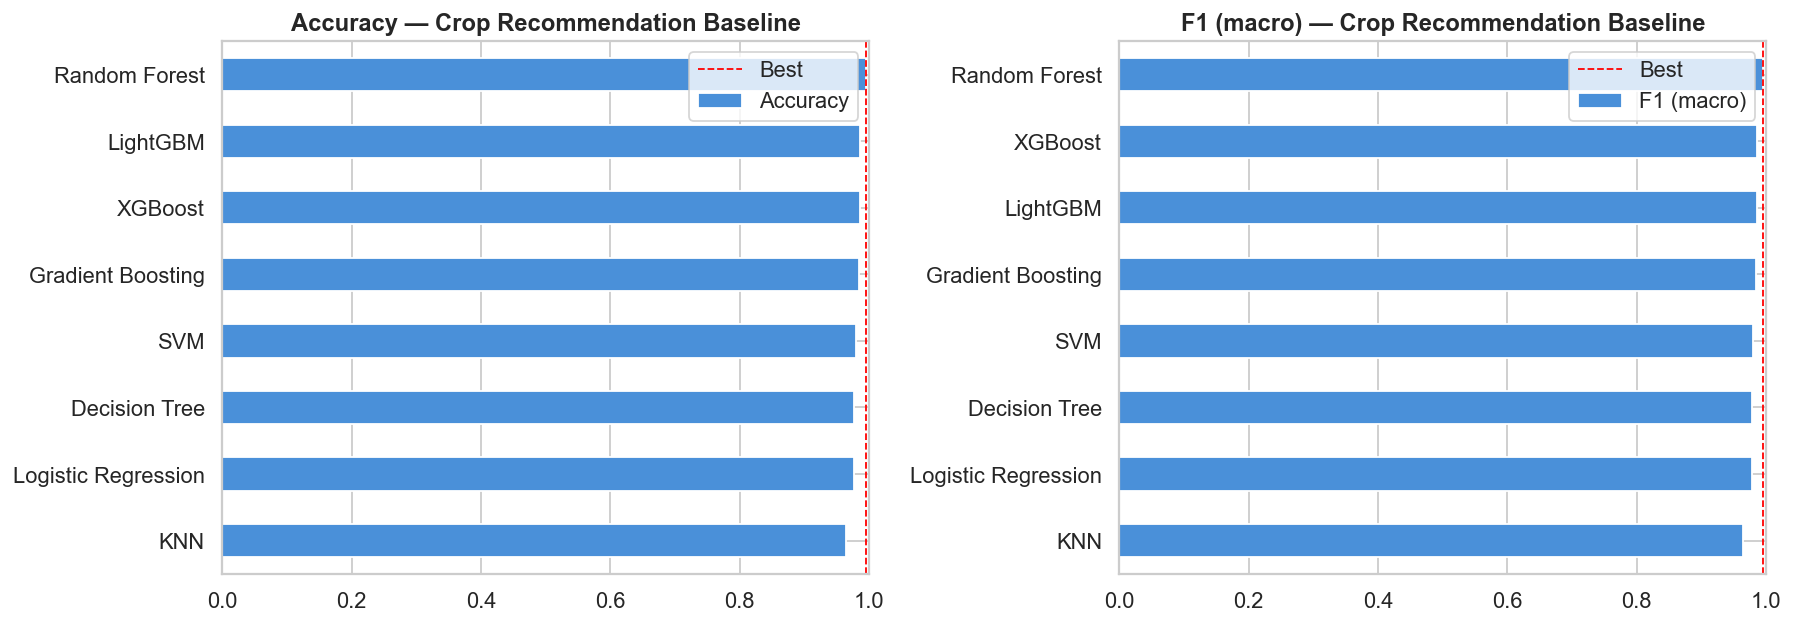

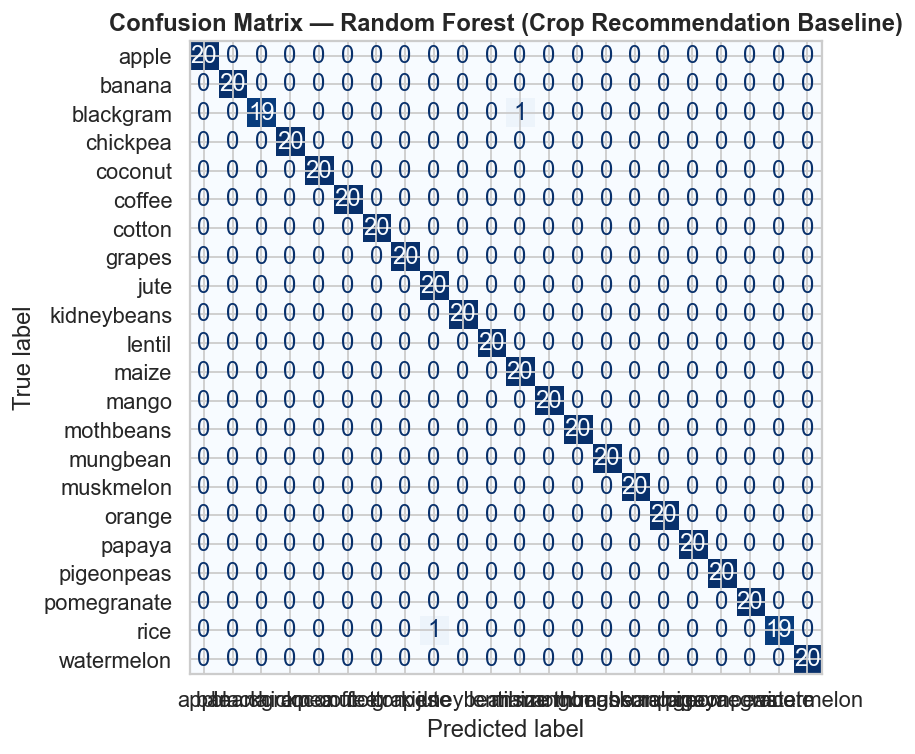


Best model: Random Forest


In [19]:
print("=" * 60)
print("TASK 2 — Baseline: All Models on Real Crop Dataset")
print("=" * 60)

df_crop_model = df_crop.copy()
df_crop_model["NPK_sum"]   = df_crop_model["N"] + df_crop_model["P"] + df_crop_model["K"]
df_crop_model["N_P_ratio"] = df_crop_model["N"] / (df_crop_model["P"] + 1)
df_crop_model["N_K_ratio"] = df_crop_model["N"] / (df_crop_model["K"] + 1)
df_crop_model["P_K_ratio"] = df_crop_model["P"] / (df_crop_model["K"] + 1)
df_crop_model["temp_hum"]  = df_crop_model["temperature"] * df_crop_model["humidity"] / 100
df_crop_model["ph_sq"]     = df_crop_model["ph"] ** 2

features_t2 = [
    "N", "P", "K", "temperature", "humidity", "ph", "rainfall",
    "NPK_sum", "N_P_ratio", "N_K_ratio", "P_K_ratio", "temp_hum", "ph_sq"
]

X_t2 = df_crop_model[features_t2]
y_t2 = le_crop_real.transform(df_crop_model["label"])

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_t2, y_t2, test_size=0.2, stratify=y_t2, random_state=42)

print(f"Train: {X_train2.shape}  Test: {X_test2.shape}  Classes: {df_crop['label'].nunique()}\n")

results_t2, trained_t2, best_t2_baseline = compare_classifiers(
    X_train2, X_test2, y_train2, y_test2,
    task_name="Crop Recommendation Baseline",
    label_names=le_crop_real.classes_)


TASK 2 — Hyperparameter Tuning (RandomizedSearchCV)
Fitting 5 folds for each of 25 candidates, totalling 125 fits

RF best params : {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}
RF tuned        Acc=0.9955  F1=0.9955
Fitting 5 folds for each of 25 candidates, totalling 125 fits

XGB best params : {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
XGB tuned       Acc=0.9955  F1=0.9954
Fitting 5 folds for each of 25 candidates, totalling 125 fits


/Users/macbook/Documents/Flower-prediction/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/macbook/Documents/Flower-prediction/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/macbook/Documents/Flower-prediction/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/macbook/Documents/Flower-prediction/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/macbook/Documents/Flower-prediction/venv/lib/python3.9/site-packages/sklearn/utils/valida


LGBM best params: {'subsample': 1.0, 'num_leaves': 127, 'n_estimators': 500, 'min_child_samples': 30, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
LGBM tuned      Acc=0.9955  F1=0.9954


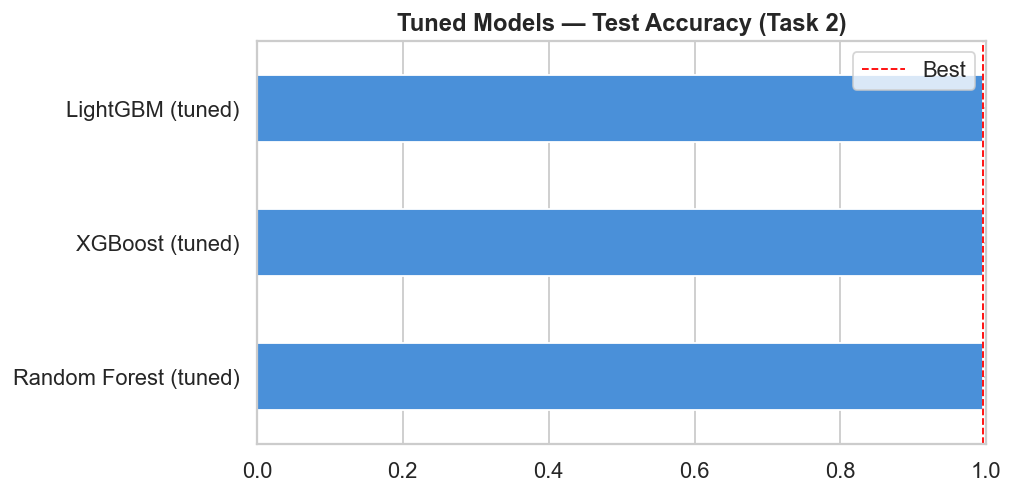

In [20]:
print("=" * 60)
print("TASK 2 — Hyperparameter Tuning (RandomizedSearchCV)")
print("=" * 60)

scaler_t2   = StandardScaler()
X_train2_sc = scaler_t2.fit_transform(X_train2)
X_test2_sc  = scaler_t2.transform(X_test2)

# Random Forest tuning
rf_params = {
    "n_estimators":     [200, 400, 600],
    "max_depth":        [None, 10, 20, 30],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features":     ["sqrt", "log2"],
}
rf_rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, n_iter=25, scoring="accuracy", cv=5,
    n_jobs=-1, random_state=42, verbose=1)
rf_rs.fit(X_train2_sc, y_train2)
rf_best    = rf_rs.best_estimator_
y_pred_rf  = rf_best.predict(X_test2_sc)
print(f"\nRF best params : {rf_rs.best_params_}")
print(f"RF tuned        Acc={accuracy_score(y_test2, y_pred_rf):.4f}  "
      f"F1={f1_score(y_test2, y_pred_rf, average='macro'):.4f}")

# XGBoost tuning
xgb_params = {
    "n_estimators":     [300, 500, 700],
    "max_depth":        [4, 6, 8],
    "learning_rate":    [0.05, 0.1, 0.15],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3],
}
xgb_rs = RandomizedSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric="mlogloss",
                  random_state=42, verbosity=0),
    xgb_params, n_iter=25, scoring="accuracy", cv=5,
    n_jobs=-1, random_state=42, verbose=1)
xgb_rs.fit(X_train2_sc, y_train2)
xgb_best    = xgb_rs.best_estimator_
y_pred_xgb  = xgb_best.predict(X_test2_sc)
print(f"\nXGB best params : {xgb_rs.best_params_}")
print(f"XGB tuned       Acc={accuracy_score(y_test2, y_pred_xgb):.4f}  "
      f"F1={f1_score(y_test2, y_pred_xgb, average='macro'):.4f}")

# LightGBM tuning
lgbm_params = {
    "n_estimators":       [300, 500, 700],
    "max_depth":          [4, 6, 8, -1],
    "learning_rate":      [0.05, 0.1, 0.15],
    "num_leaves":         [31, 63, 127],
    "min_child_samples":  [10, 20, 30],
    "subsample":          [0.8, 1.0],
    "colsample_bytree":   [0.8, 1.0],
}
lgbm_rs = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbosity=-1),
    lgbm_params, n_iter=25, scoring="accuracy", cv=5,
    n_jobs=-1, random_state=42, verbose=1)
lgbm_rs.fit(X_train2_sc, y_train2)
lgbm_best    = lgbm_rs.best_estimator_
y_pred_lgbm  = lgbm_best.predict(X_test2_sc)
print(f"\nLGBM best params: {lgbm_rs.best_params_}")
print(f"LGBM tuned      Acc={accuracy_score(y_test2, y_pred_lgbm):.4f}  "
      f"F1={f1_score(y_test2, y_pred_lgbm, average='macro'):.4f}")

# Tuning comparison chart
tuned_results = {
    "Random Forest (tuned)": accuracy_score(y_test2, y_pred_rf),
    "XGBoost (tuned)":       accuracy_score(y_test2, y_pred_xgb),
    "LightGBM (tuned)":      accuracy_score(y_test2, y_pred_lgbm),
}
fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(tuned_results).sort_values().plot(kind="barh", ax=ax, color="#4A90D9", edgecolor="white")
ax.set_xlim(0, 1)
ax.set_title("Tuned Models — Test Accuracy (Task 2)", fontweight="bold")
ax.axvline(max(tuned_results.values()), color="red", linestyle="--", lw=1, label="Best")
ax.legend()
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/models/task2_tuned_comparison.png", bbox_inches="tight")
plt.show()


Final model: Random Forest (tuned)
5-fold CV  Accuracy: 0.9938 ± 0.0045
Test       Accuracy: 0.9955
Test       F1 macro: 0.9955

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00    

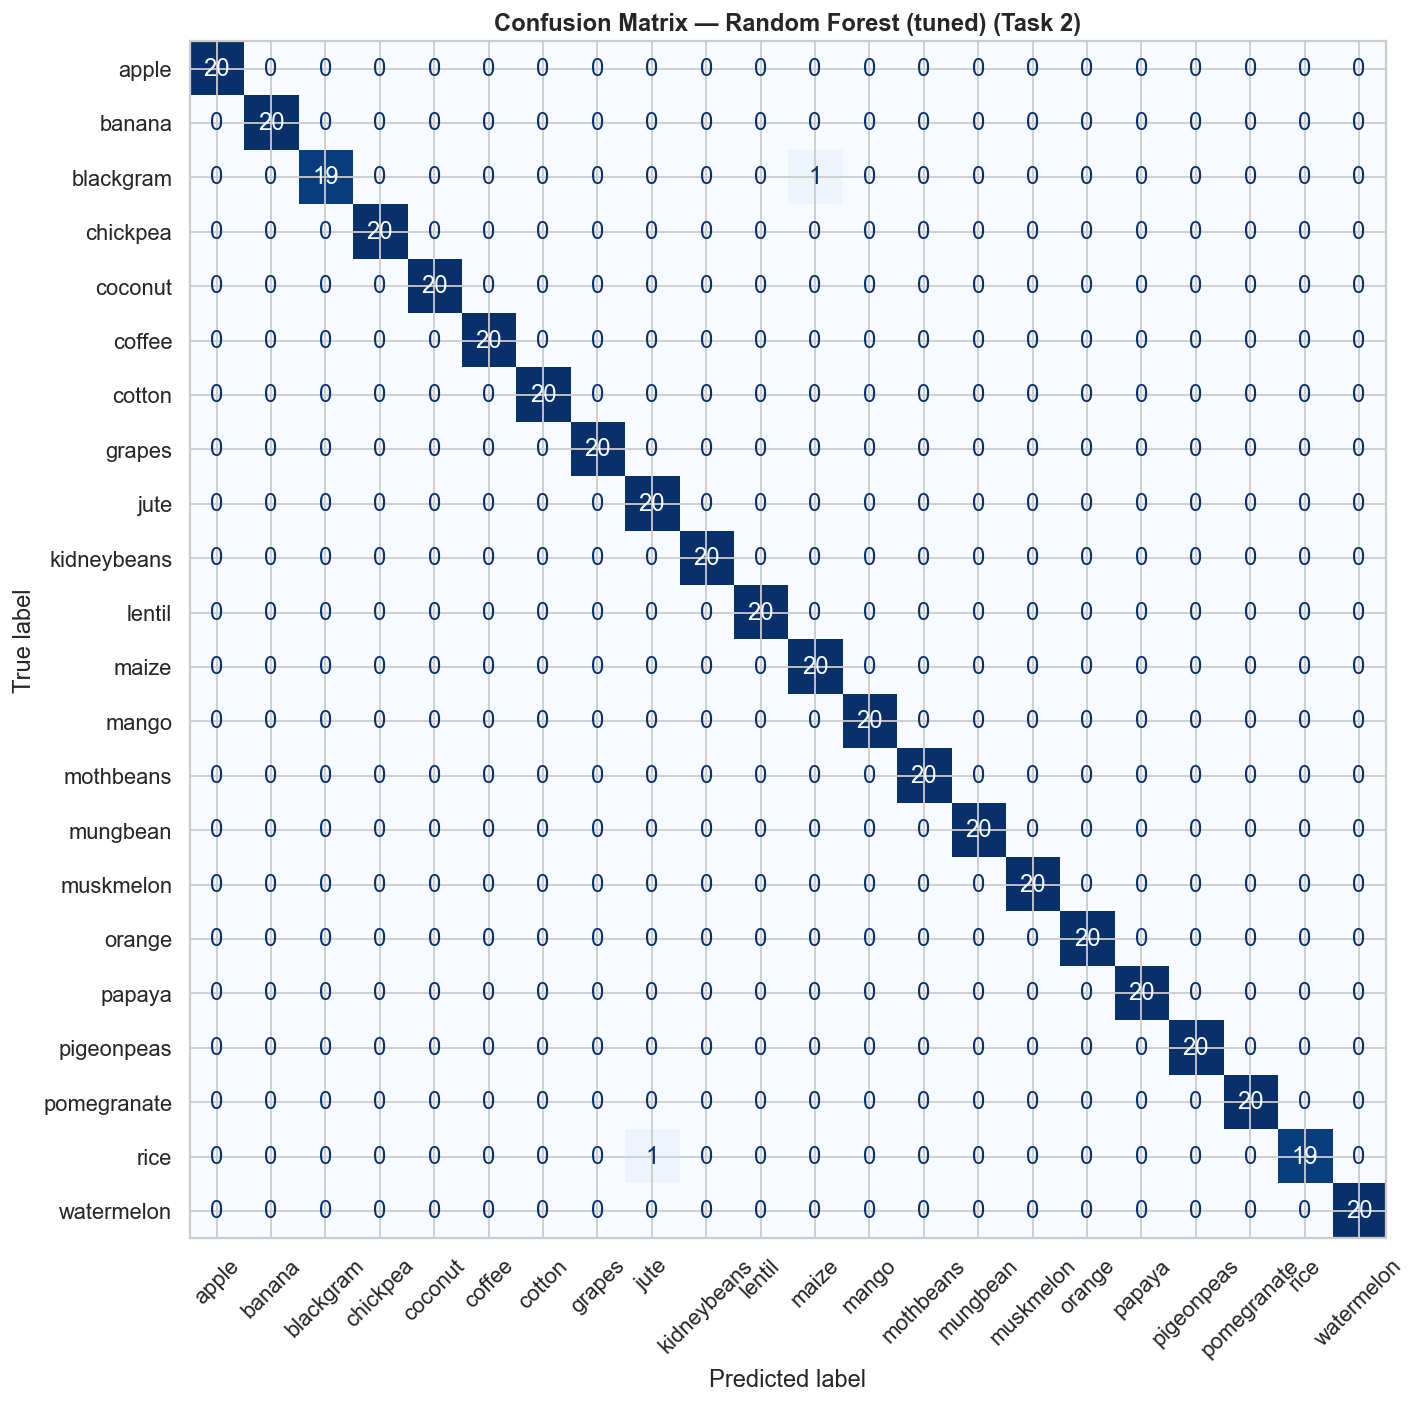

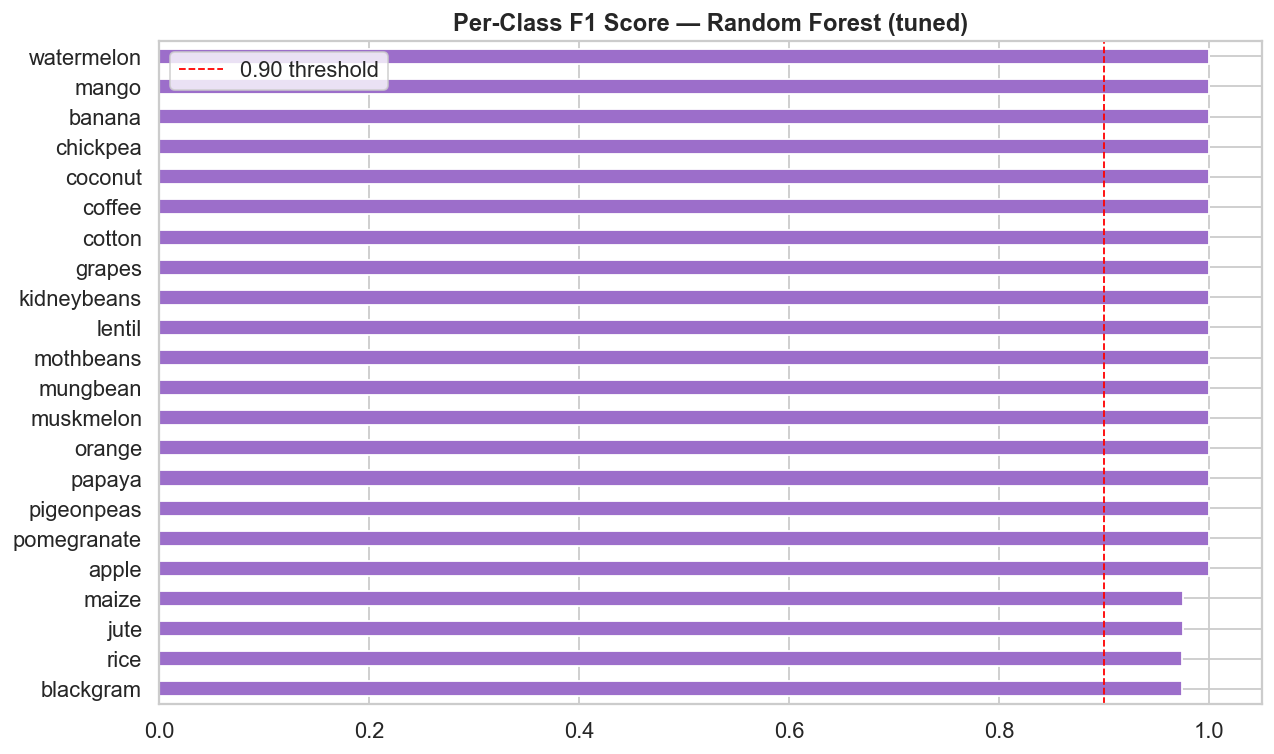

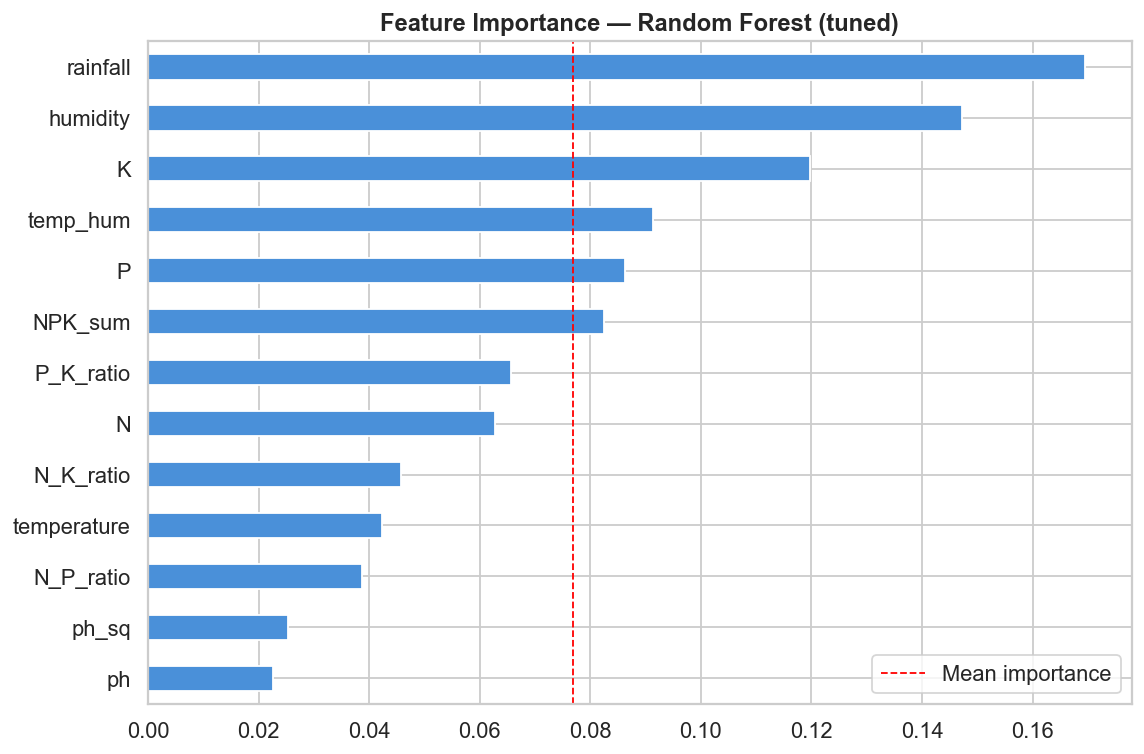


Saved: task2_crop_recommendation_best.pkl  (Random Forest (tuned))


In [21]:
# Pick the best tuned model
scores_map = {
    "Random Forest": (rf_best,   y_pred_rf),
    "XGBoost":       (xgb_best,  y_pred_xgb),
    "LightGBM":      (lgbm_best, y_pred_lgbm),
}
final_name_t2, (final_clf_t2, y_pred_final_t2) = max(
    scores_map.items(), key=lambda x: accuracy_score(y_test2, x[1][1]))
final_name_t2 += " (tuned)"
print(f"Final model: {final_name_t2}")

# 5-fold CV
cv_t2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_t2 = cross_val_score(final_clf_t2, X_train2_sc, y_train2,
                                cv=cv_t2, scoring="accuracy", n_jobs=-1)
print(f"5-fold CV  Accuracy: {cv_scores_t2.mean():.4f} ± {cv_scores_t2.std():.4f}")
print(f"Test       Accuracy: {accuracy_score(y_test2, y_pred_final_t2):.4f}")
print(f"Test       F1 macro: {f1_score(y_test2, y_pred_final_t2, average='macro'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test2, y_pred_final_t2, target_names=le_crop_real.classes_))

# Confusion matrix
fig, ax = plt.subplots(figsize=(14, 11))
ConfusionMatrixDisplay.from_predictions(
    y_test2, y_pred_final_t2, display_labels=le_crop_real.classes_,
    ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
ax.set_title(f"Confusion Matrix — {final_name_t2} (Task 2)", fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/models/task2_final_confusion_matrix.png", bbox_inches="tight")
plt.show()

# Per-class F1
rpt = classification_report(y_test2, y_pred_final_t2,
                             target_names=le_crop_real.classes_, output_dict=True)
per_f1 = {k: v["f1-score"] for k, v in rpt.items() if k in le_crop_real.classes_}
fig, ax = plt.subplots(figsize=(10, 6))
pd.Series(per_f1).sort_values().plot(kind="barh", ax=ax, color="#9C6ECA", edgecolor="white")
ax.set_title(f"Per-Class F1 Score — {final_name_t2}", fontweight="bold")
ax.axvline(0.9, color="red", linestyle="--", lw=1, label="0.90 threshold")
ax.legend()
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/models/task2_per_class_f1.png", bbox_inches="tight")
plt.show()

# Feature importance
if hasattr(final_clf_t2, "feature_importances_"):
    feat_imp = pd.Series(final_clf_t2.feature_importances_,
                         index=features_t2).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(9, 6))
    feat_imp.plot(kind="barh", ax=ax, color="#4A90D9", edgecolor="white")
    ax.axvline(feat_imp.mean(), color="red", linestyle="--", lw=1, label="Mean importance")
    ax.set_title(f"Feature Importance — {final_name_t2}", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.savefig("../visualizations/soil_prediction/models/task2_feature_importance.png", bbox_inches="tight")
    plt.show()

# Save full pipeline (refit on all data)
final_pipe_t2 = Pipeline([("scaler", scaler_t2), ("clf", final_clf_t2)])
final_pipe_t2.fit(X_t2, y_t2)
joblib.dump(final_pipe_t2,    "../models/soil_prediction/task2_crop_recommendation_best.pkl")
joblib.dump(le_crop_real,     "../models/soil_prediction/task2_label_encoder_crop.pkl")
joblib.dump(features_t2,      "../models/soil_prediction/task2_feature_names.pkl")
print(f"\nSaved: task2_crop_recommendation_best.pkl  ({final_name_t2})")


# Task 3a: Fertilizer Prescription (Multi-class Classification)

TASK 3a — Fertilizer Prescription (Classification)
  Logistic Regression        Acc=0.1469  F1=0.1279
  Decision Tree              Acc=0.1437  F1=0.1438
  Random Forest              Acc=0.1363  F1=0.1359
  SVM                        Acc=0.1425  F1=0.1393
  KNN                        Acc=0.1394  F1=0.1378
  Gradient Boosting          Acc=0.1419  F1=0.1415
  XGBoost                    Acc=0.1444  F1=0.1444
  LightGBM                   Acc=0.1419  F1=0.1421


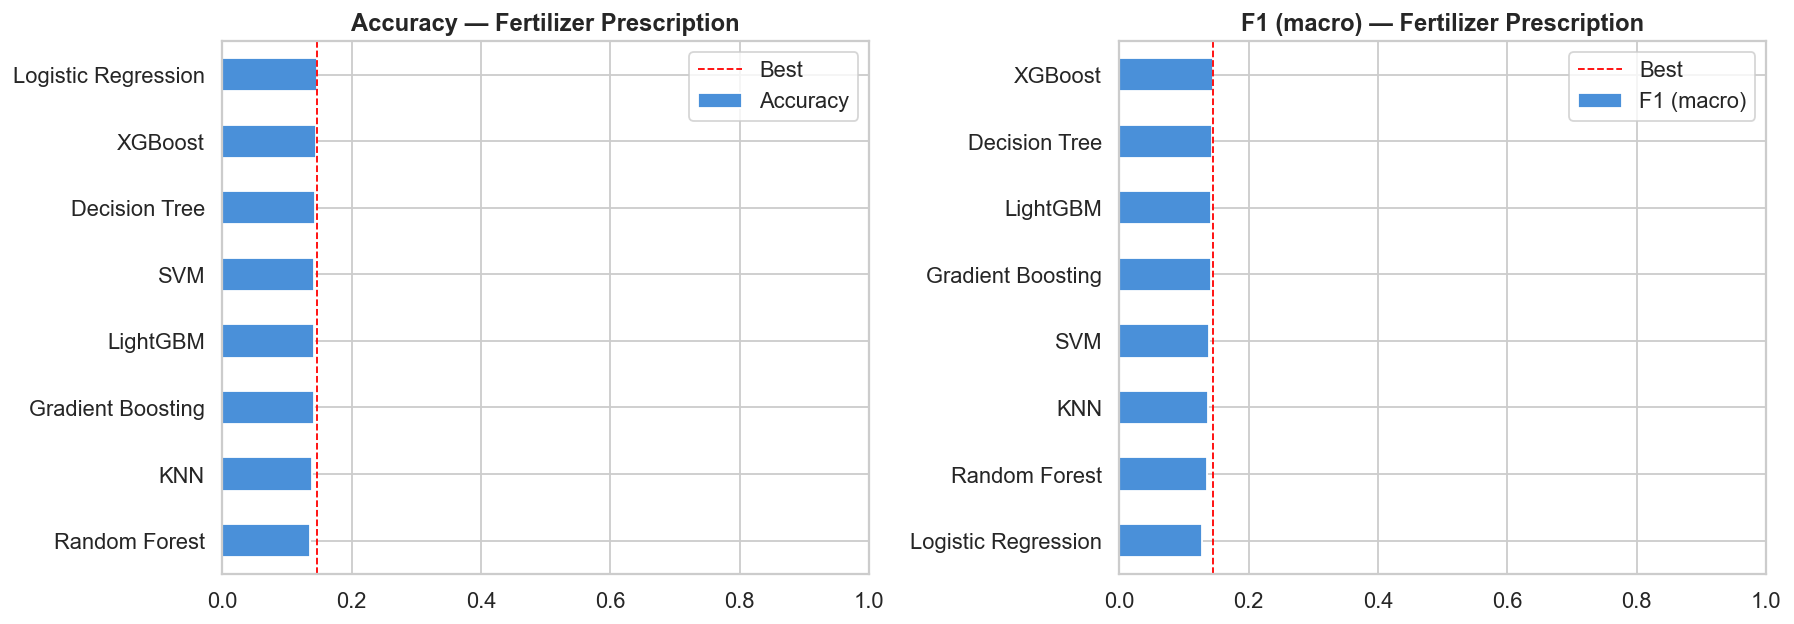

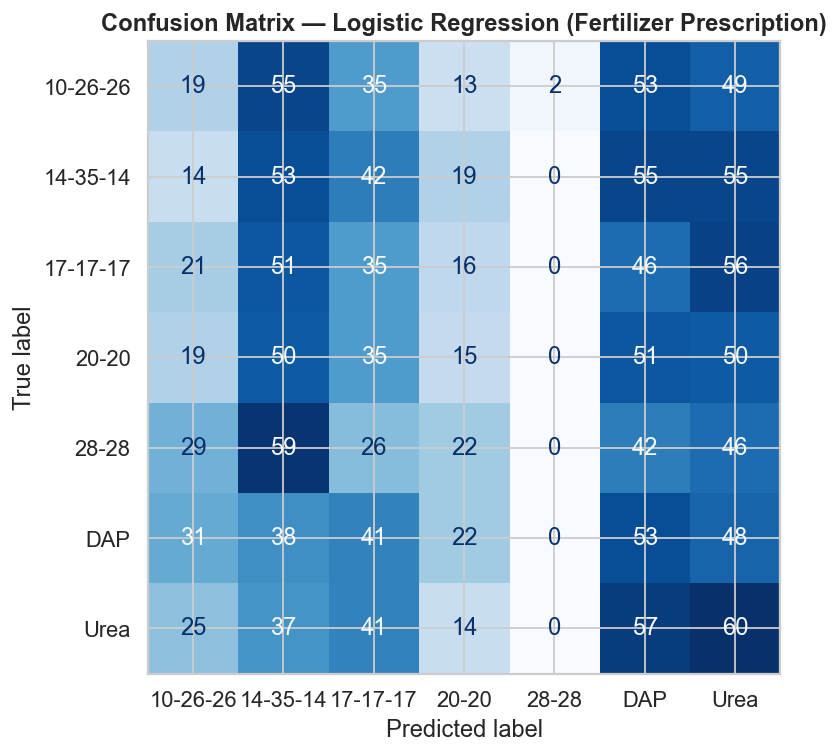


Best model: Logistic Regression
5-fold CV Accuracy: 0.1451 ± 0.0061

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

    10-26-26       0.12      0.08      0.10       226
    14-35-14       0.15      0.22      0.18       238
    17-17-17       0.14      0.16      0.15       225
       20-20       0.12      0.07      0.09       220
       28-28       0.00      0.00      0.00       224
         DAP       0.15      0.23      0.18       233
        Urea       0.16      0.26      0.20       234

    accuracy                           0.15      1600
   macro avg       0.12      0.14      0.13      1600
weighted avg       0.12      0.15      0.13      1600

Saved: task3_fertilizer_prescription_best.pkl  (Logistic Regression)


,Accuracy,F1 (macro)
Logistic Regression,0.146875,0.127935
XGBoost,0.144375,0.144361
Decision Tree,0.143750,0.143837
SVM,0.142500,0.139320
Gradient Boosting,0.141875,0.141451
LightGBM,0.141875,0.142112
KNN,0.139375,0.137846
Random Forest,0.136250,0.135881


In [22]:
print("=" * 60)
print("TASK 3a — Fertilizer Prescription (Classification)")
print("=" * 60)

features_t3 = ["Nitrogen", "Potassium", "Phosphorous",
                "Temparature", "Humidity", "Moisture",
                "NPK_sum", "N_P_ratio", "N_K_ratio",
                "Soil_Type_enc", "Crop_Type_enc"]

X_t3 = df_model[features_t3]
y_t3 = df_model["Fert_Name_enc"]

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_t3, y_t3, test_size=0.2, stratify=y_t3, random_state=42)

results_t3, trained_t3, best_t3 = compare_classifiers(
    X_train3, X_test3, y_train3, y_test3,
    task_name="Fertilizer Prescription", label_names=le_fert.classes_)

best_pipe_t3 = trained_t3[best_t3]

if hasattr(best_pipe_t3["clf"], "feature_importances_"):
    feat_df = pd.Series(best_pipe_t3["clf"].feature_importances_,
                        index=features_t3).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    feat_df.plot(kind="barh", ax=ax, color="#E07B54", edgecolor="white")
    ax.set_title(f"Feature Importance — {best_t3} (Task 3a)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("../visualizations/soil_prediction/models/task3_feature_importance.png", bbox_inches="tight")
    plt.show()

cv_scores3 = cross_val_score(best_pipe_t3, X_t3, y_t3, cv=5, scoring="accuracy")
print(f"5-fold CV Accuracy: {cv_scores3.mean():.4f} ± {cv_scores3.std():.4f}")
print(f"\nClassification Report ({best_t3}):")
print(classification_report(y_test3, best_pipe_t3.predict(X_test3), target_names=le_fert.classes_))

joblib.dump(best_pipe_t3, "../models/soil_prediction/task3_fertilizer_prescription_best.pkl")
joblib.dump(le_fert,      "../models/soil_prediction/task3_label_encoder_fert.pkl")
print(f"Saved: task3_fertilizer_prescription_best.pkl  ({best_t3})")
results_t3


# Task 3b: Nutrient Regression (N, P, K)

TASK 3b — Nutrient Regression (predict N, P, K levels)

──────────────────────────────────────────────────
Predicting: Nitrogen
──────────────────────────────────────────────────
  Ridge Regression        RMSE=11.741  R²=0.0095
  Random Forest           RMSE=11.916  R²=-0.0204
  SVR                     RMSE=12.056  R²=-0.0445
  XGBoost                 RMSE=12.838  R²=-0.1844
  LightGBM                RMSE=11.998  R²=-0.0345


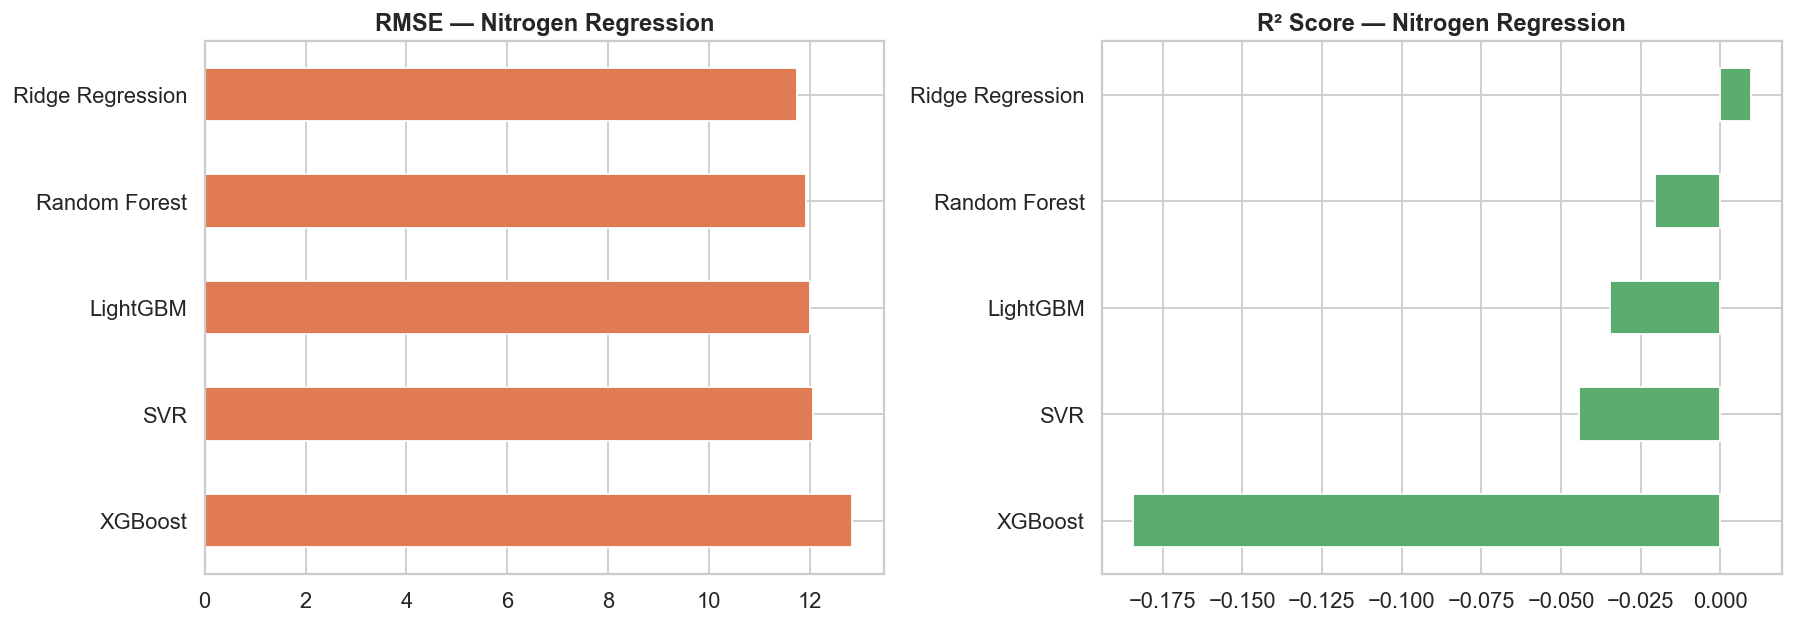


Best model: Ridge Regression


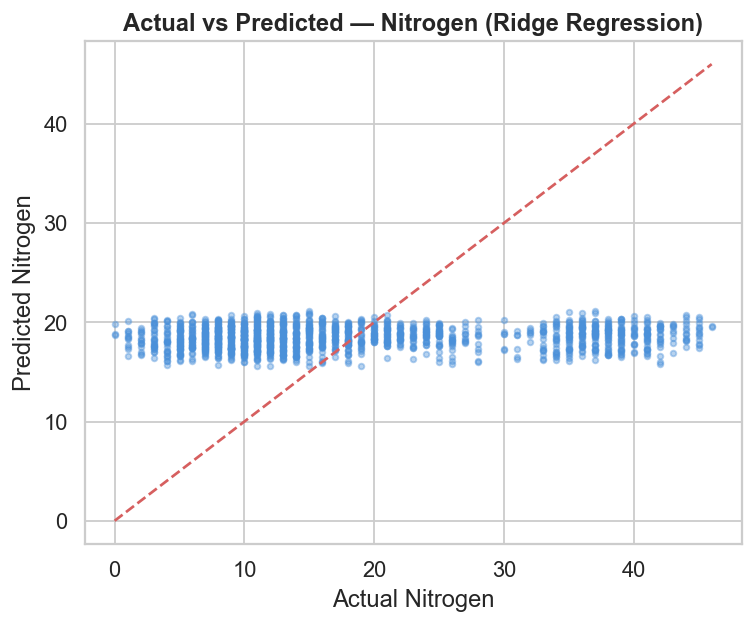

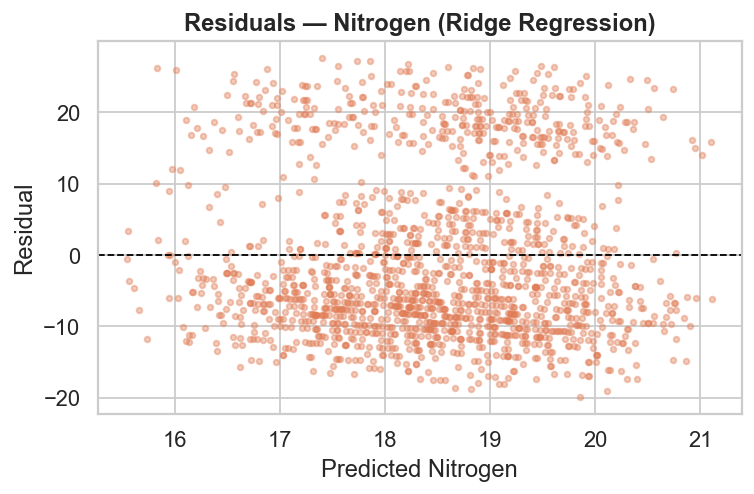

  Saved: task3b_nitrogen_regression_best.pkl  (Ridge Regression)

──────────────────────────────────────────────────
Predicting: Potassium
──────────────────────────────────────────────────
  Ridge Regression        RMSE=5.487  R²=-0.0009
  Random Forest           RMSE=5.562  R²=-0.0283
  SVR                     RMSE=5.921  R²=-0.1657
  XGBoost                 RMSE=5.907  R²=-0.1598
  LightGBM                RMSE=5.566  R²=-0.0298


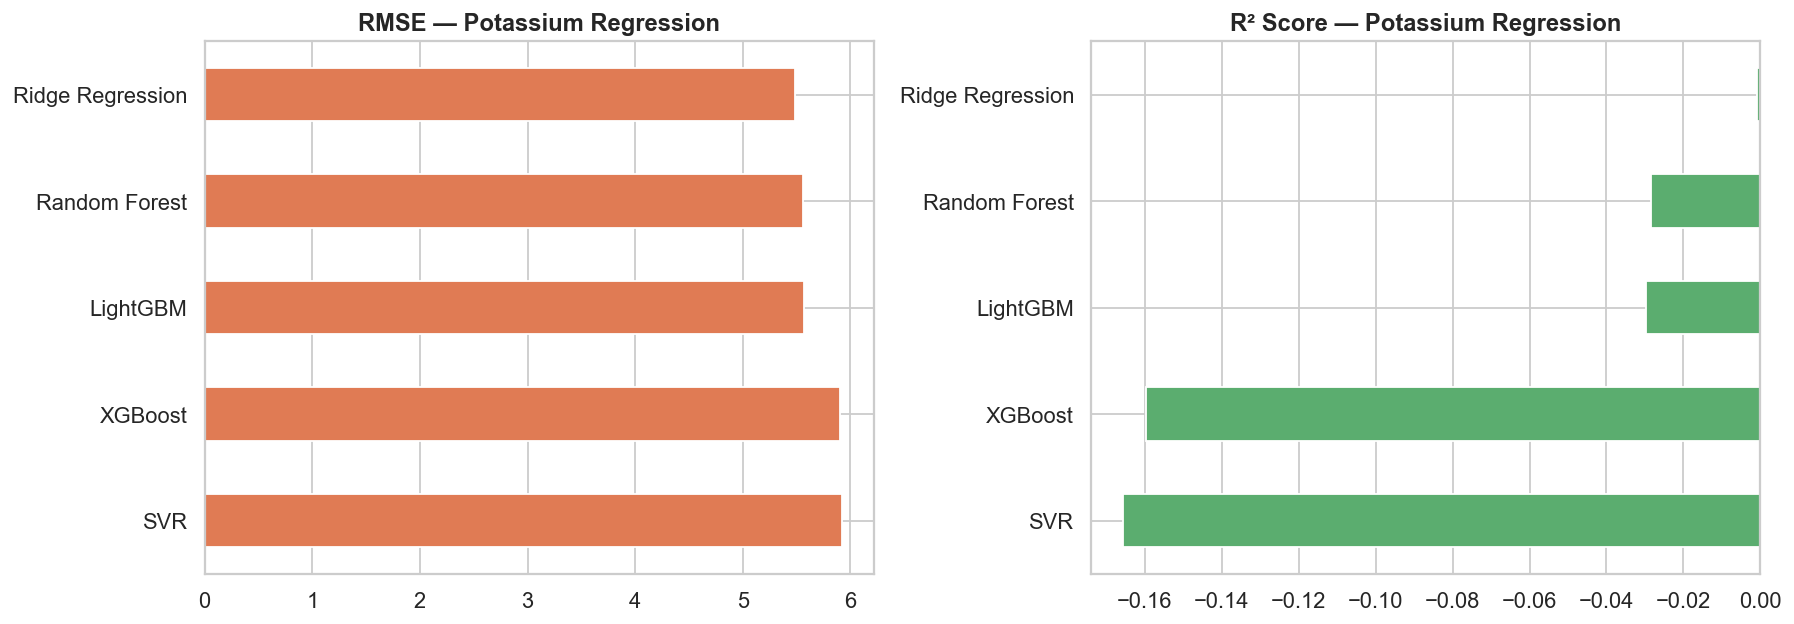


Best model: Ridge Regression


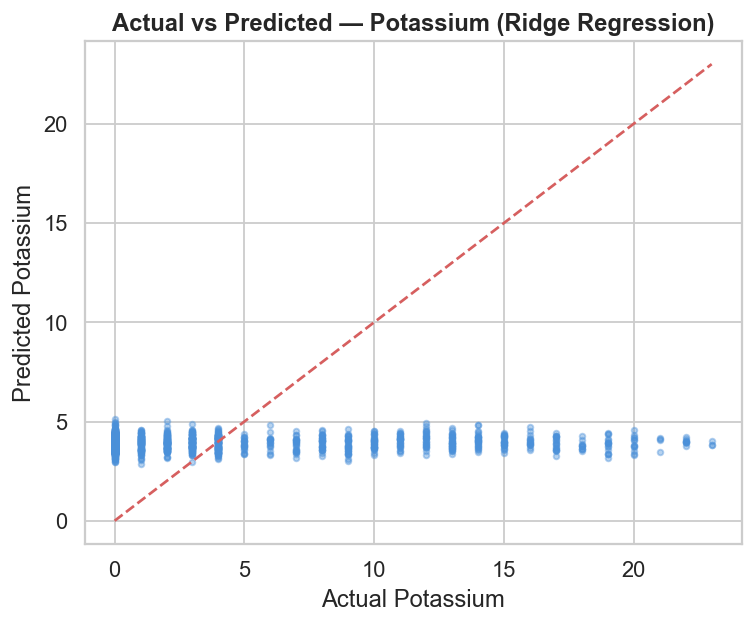

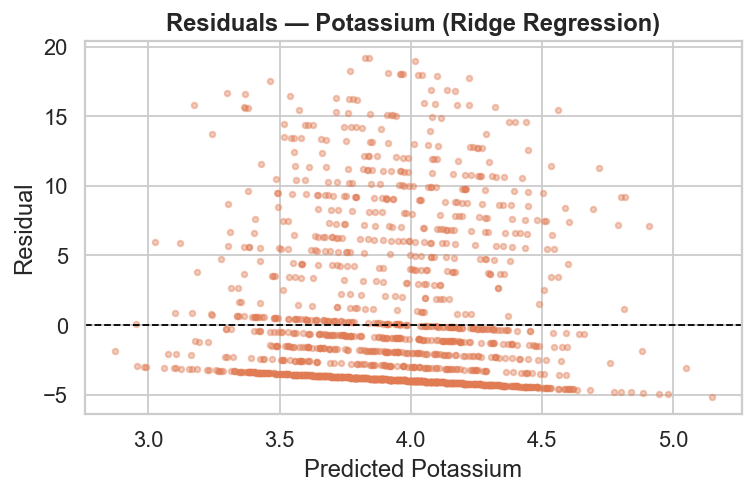

  Saved: task3b_potassium_regression_best.pkl  (Ridge Regression)

──────────────────────────────────────────────────
Predicting: Phosphorous
──────────────────────────────────────────────────
  Ridge Regression        RMSE=12.942  R²=0.0435
  Random Forest           RMSE=13.065  R²=0.0253
  SVR                     RMSE=12.956  R²=0.0415
  XGBoost                 RMSE=13.933  R²=-0.1085
  LightGBM                RMSE=13.089  R²=0.0218


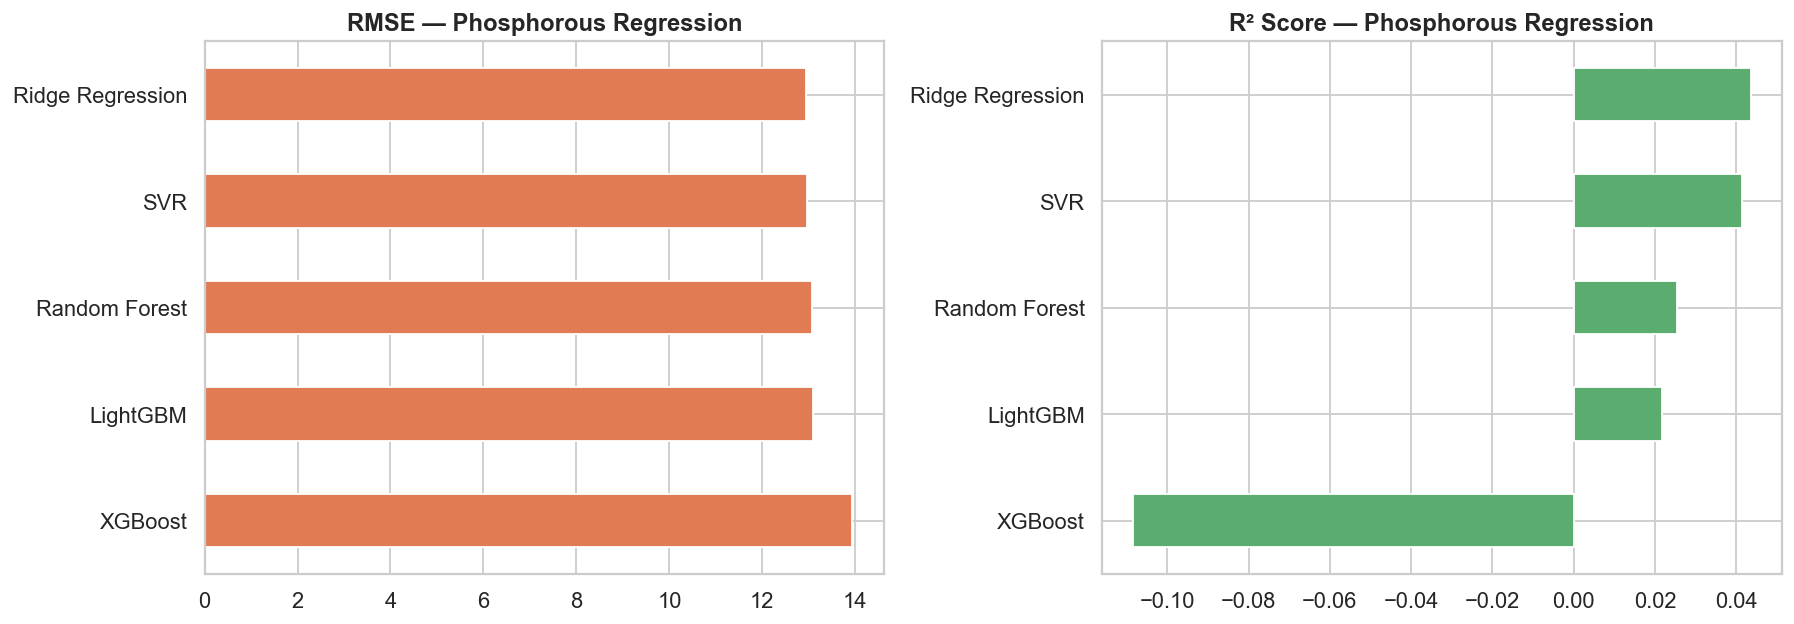


Best model: Ridge Regression


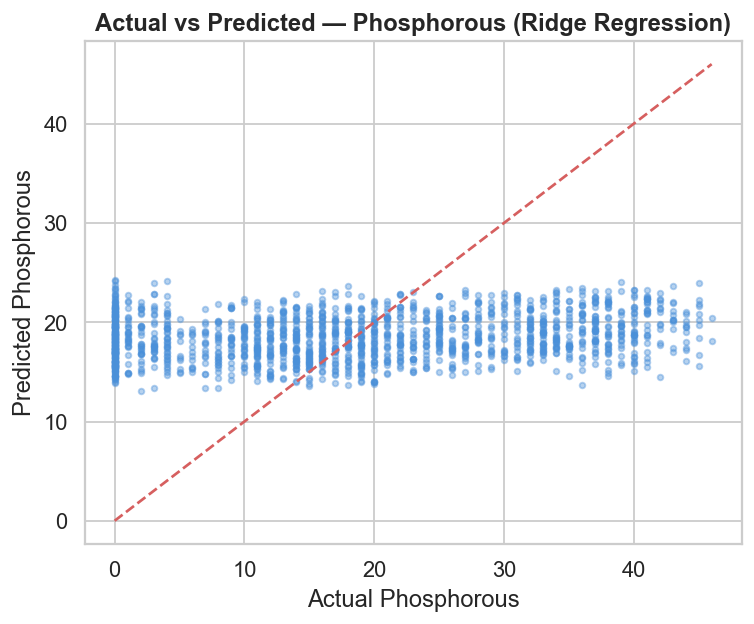

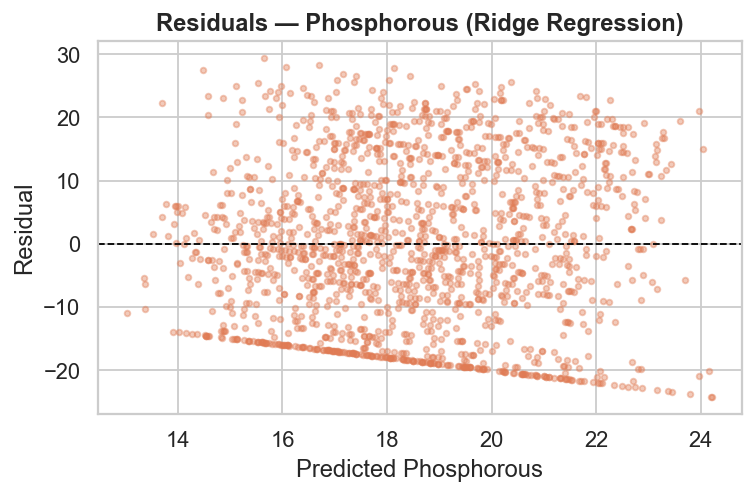

  Saved: task3b_phosphorous_regression_best.pkl  (Ridge Regression)


In [23]:
print("=" * 60)
print("TASK 3b — Nutrient Regression (predict N, P, K levels)")
print("=" * 60)

features_reg = ["Temparature", "Humidity", "Moisture",
                "Soil_Type_enc", "Crop_Type_enc"]

reg_best_models = {}

for nutrient in ["Nitrogen", "Potassium", "Phosphorous"]:
    print(f"\n{'─'*50}")
    print(f"Predicting: {nutrient}")
    print(f"{'─'*50}")
    X_r = df_model[features_reg]
    y_r = df_model[nutrient]

    X_tr, X_te, y_tr, y_te = train_test_split(X_r, y_r, test_size=0.2, random_state=42)
    results_r, trained_r, best_r = compare_regressors(
        X_tr, X_te, y_tr, y_te, task_name=f"{nutrient} Regression")

    best_pipe_r = trained_r[best_r]
    y_pred_r    = best_pipe_r.predict(X_te)

    # Actual vs Predicted scatter
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_te, y_pred_r, alpha=0.4, s=10, color="#4A90D9")
    ax.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], "r--", lw=1.5)
    ax.set_xlabel(f"Actual {nutrient}")
    ax.set_ylabel(f"Predicted {nutrient}")
    ax.set_title(f"Actual vs Predicted — {nutrient} ({best_r})", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"../visualizations/soil_prediction/models/task3b_{nutrient.lower()}_actual_vs_pred.png",
                bbox_inches="tight")
    plt.show()

    # Residuals plot
    residuals = y_te - y_pred_r
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(y_pred_r, residuals, alpha=0.4, s=10, color="#E07B54")
    ax.axhline(0, color="black", linestyle="--", lw=1)
    ax.set_xlabel(f"Predicted {nutrient}")
    ax.set_ylabel("Residual")
    ax.set_title(f"Residuals — {nutrient} ({best_r})", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"../visualizations/soil_prediction/models/task3b_{nutrient.lower()}_residuals.png",
                bbox_inches="tight")
    plt.show()

    joblib.dump(best_pipe_r,
                f"../models/soil_prediction/task3b_{nutrient.lower()}_regression_best.pkl")
    print(f"  Saved: task3b_{nutrient.lower()}_regression_best.pkl  ({best_r})")
    reg_best_models[nutrient] = (best_r, best_pipe_r)


# Task 4: Soil Salinity & Stress Index

TASK 4 — Soil Salinity & Stress Index Classification
Class balance:
Salinity_Stress
0    7550
1     450
Name: count, dtype: int64
  Logistic Regression        Acc=0.9675  F1=0.8348
  Decision Tree              Acc=1.0000  F1=1.0000
  Random Forest              Acc=0.9994  F1=0.9970
  SVM                        Acc=0.9825  F1=0.9149
  KNN                        Acc=0.9731  F1=0.8506
  Gradient Boosting          Acc=1.0000  F1=1.0000
  XGBoost                    Acc=0.9994  F1=0.9970
  LightGBM                   Acc=0.9975  F1=0.9881


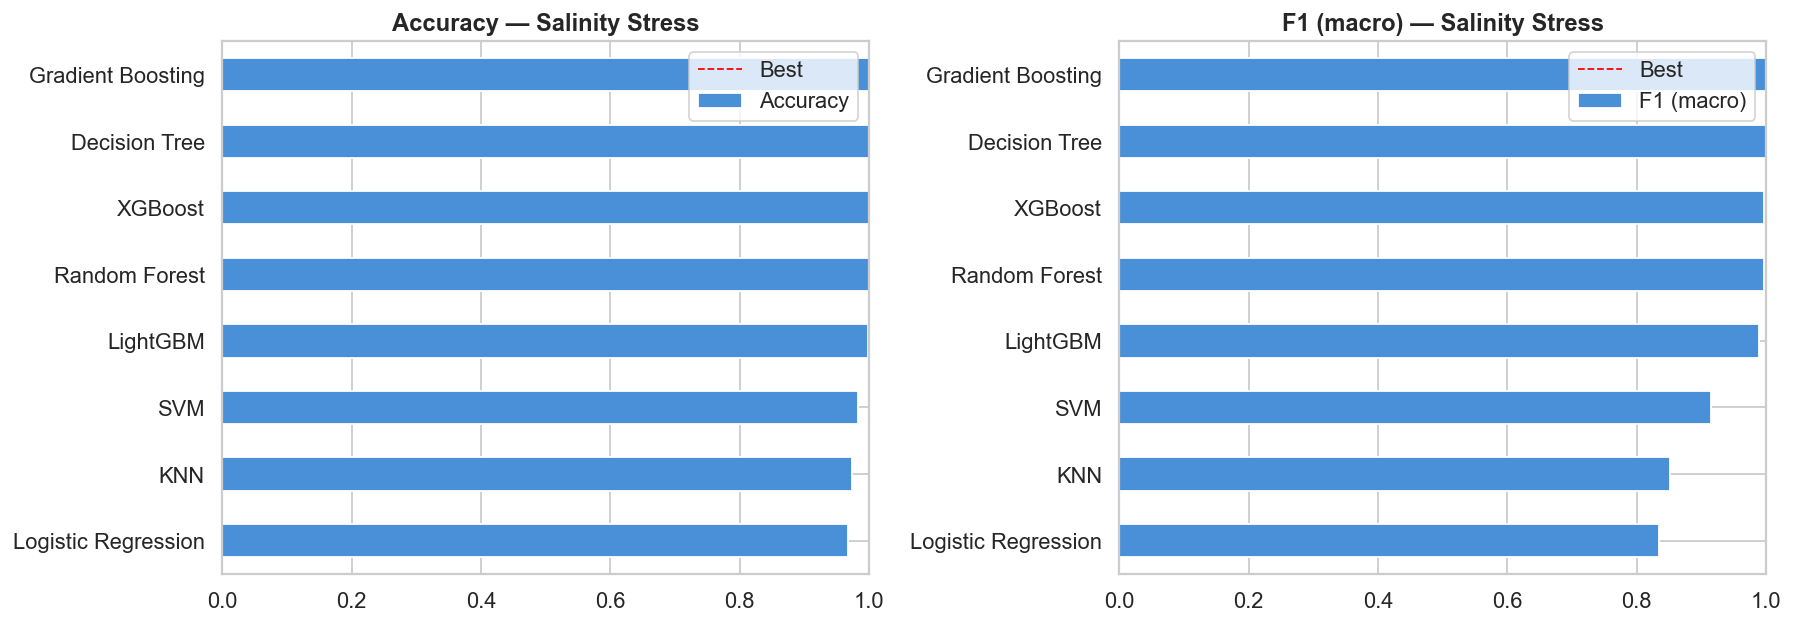

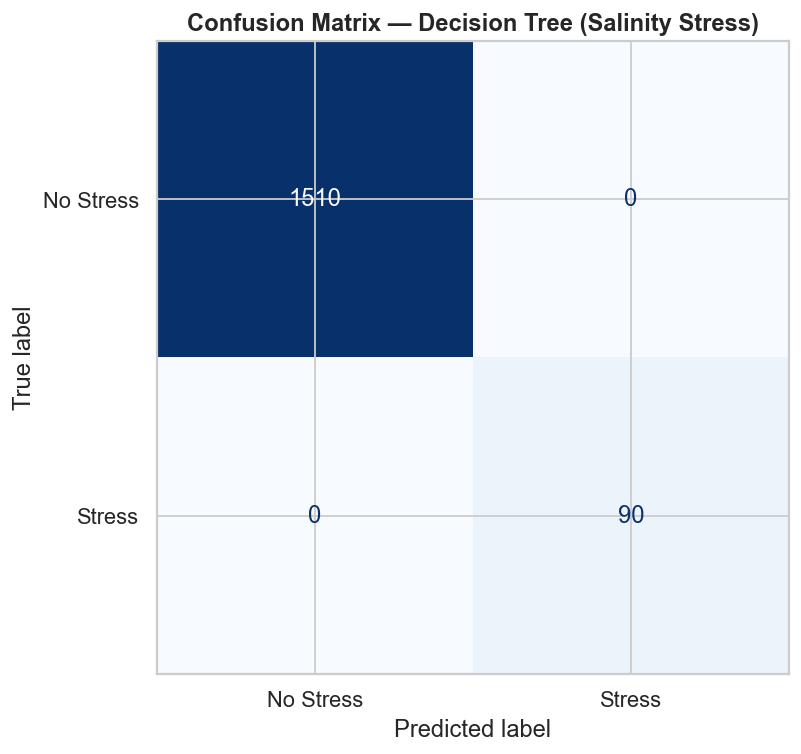


Best model: Decision Tree


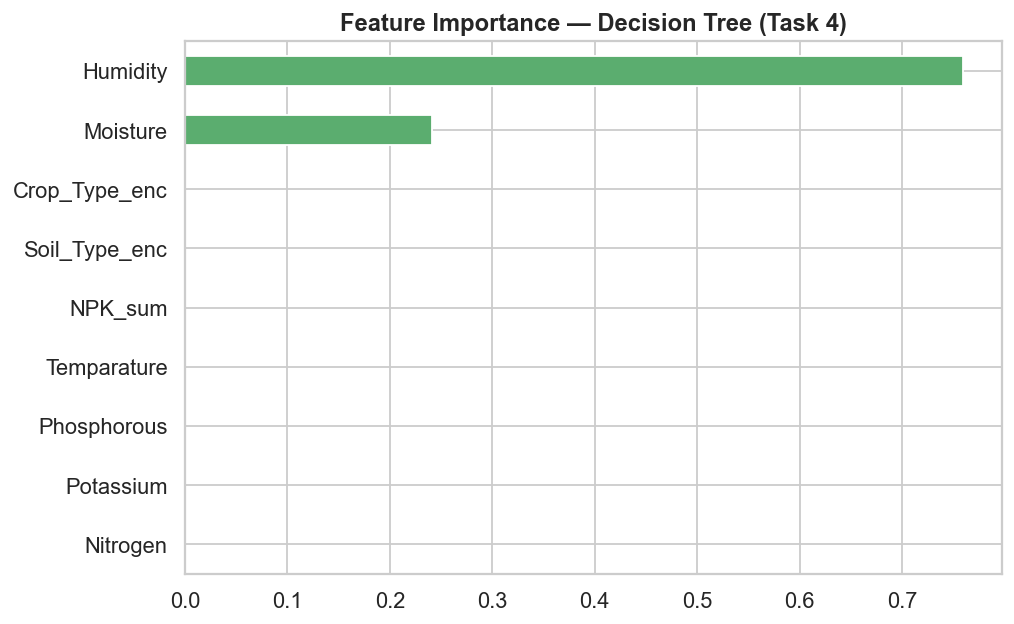

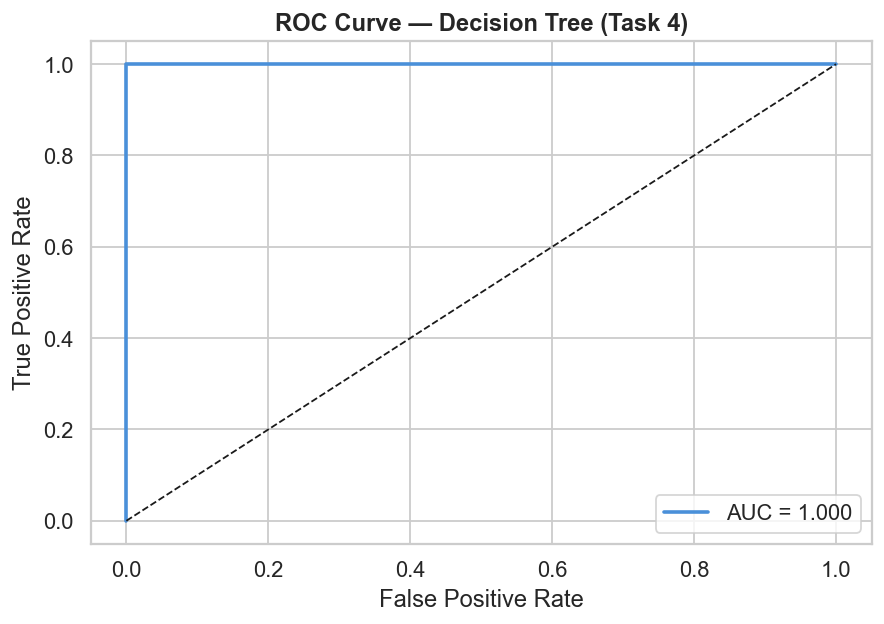

ROC AUC: 1.0000
5-fold CV Accuracy: 0.9999 ± 0.0002

Classification Report (Decision Tree):
              precision    recall  f1-score   support

   No Stress       1.00      1.00      1.00      1510
      Stress       1.00      1.00      1.00        90

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600

Saved: task4_salinity_stress_best.pkl  (Decision Tree)


,Accuracy,F1 (macro)
Decision Tree,1.000000,1.000000
Gradient Boosting,1.000000,1.000000
Random Forest,0.999375,0.997041
XGBoost,0.999375,0.997041
LightGBM,0.997500,0.988102
SVM,0.982500,0.914914
KNN,0.973125,0.850564
Logistic Regression,0.967500,0.834804


In [24]:
print("=" * 60)
print("TASK 4 — Soil Salinity & Stress Index Classification")
print("=" * 60)

features_t4 = ["Nitrogen", "Potassium", "Phosphorous",
                "Temparature", "Humidity", "Moisture",
                "NPK_sum", "Soil_Type_enc", "Crop_Type_enc"]

X_t4 = df_model[features_t4]
y_t4 = df_model["Salinity_Stress"]

print(f"Class balance:\n{y_t4.value_counts()}")

X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X_t4, y_t4, test_size=0.2, stratify=y_t4, random_state=42)

results_t4, trained_t4, best_t4 = compare_classifiers(
    X_train4, X_test4, y_train4, y_test4,
    task_name="Salinity Stress", label_names=["No Stress", "Stress"])

best_pipe_t4 = trained_t4[best_t4]

# Feature importance
if hasattr(best_pipe_t4["clf"], "feature_importances_"):
    feat_df = pd.Series(best_pipe_t4["clf"].feature_importances_,
                        index=features_t4).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    feat_df.plot(kind="barh", ax=ax, color="#5BAD6F", edgecolor="white")
    ax.set_title(f"Feature Importance — {best_t4} (Task 4)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("../visualizations/soil_prediction/models/task4_feature_importance.png", bbox_inches="tight")
    plt.show()

# ROC Curve
if hasattr(best_pipe_t4["clf"], "predict_proba"):
    y_prob4 = best_pipe_t4.predict_proba(X_test4)[:, 1]
    fpr, tpr, _ = roc_curve(y_test4, y_prob4)
    roc_auc = auc(fpr, tpr)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, color="#4A90D9", lw=2, label=f"AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve — {best_t4} (Task 4)", fontweight="bold")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("../visualizations/soil_prediction/models/task4_roc_curve.png", bbox_inches="tight")
    plt.show()
    print(f"ROC AUC: {roc_auc:.4f}")

cv_scores4 = cross_val_score(best_pipe_t4, X_t4, y_t4, cv=5, scoring="accuracy")
print(f"5-fold CV Accuracy: {cv_scores4.mean():.4f} ± {cv_scores4.std():.4f}")
print(f"\nClassification Report ({best_t4}):")
print(classification_report(y_test4, best_pipe_t4.predict(X_test4),
                             target_names=["No Stress", "Stress"]))

joblib.dump(best_pipe_t4, "../models/soil_prediction/task4_salinity_stress_best.pkl")
print(f"Saved: task4_salinity_stress_best.pkl  ({best_t4})")
results_t4


# Summary

In [25]:
print("=" * 70)
print("FINAL SUMMARY — Best Models")
print("=" * 70)

summary_rows = [
    ("Task 1 — Soil Health Risk",        best_t1,          "Classification"),
    ("Task 2 — Crop Recommendation",     final_name_t2,    "Classification (real dataset)"),
    ("Task 3a — Fertilizer Prescription",best_t3,          "Classification"),
    ("Task 4 — Salinity Stress",         best_t4,          "Classification"),
]
for name, (nutrient, (model, _)) in reg_best_models.items():
    summary_rows.append((f"Task 3b — {name} Regression", model, "Regression"))

df_summary = pd.DataFrame(summary_rows, columns=["Task", "Best Model", "Type"])
print(df_summary.to_string(index=False))

print("\nSaved model files:")
for f in sorted(os.listdir("../models/soil_prediction")):
    print(f"  ../models/soil_prediction/{f}")

print("\nSaved visualizations:")
for folder in ["eda", "models"]:
    for f in sorted(os.listdir(f"../visualizations/soil_prediction/{folder}")):
        print(f"  ../visualizations/soil_prediction/{folder}/{f}")


FINAL SUMMARY — Best Models
                             Task            Best Model                          Type
        Task 1 — Soil Health Risk         Decision Tree                Classification
     Task 2 — Crop Recommendation Random Forest (tuned) Classification (real dataset)
Task 3a — Fertilizer Prescription   Logistic Regression                Classification
         Task 4 — Salinity Stress         Decision Tree                Classification
    Task 3b — Nitrogen Regression      StandardScaler()                    Regression
   Task 3b — Potassium Regression      StandardScaler()                    Regression
 Task 3b — Phosphorous Regression      StandardScaler()                    Regression

Saved model files:
  ../models/soil_prediction/task1_label_encoder_risk.pkl
  ../models/soil_prediction/task1_soil_risk_best.pkl
  ../models/soil_prediction/task2_crop_recommendation_best.pkl
  ../models/soil_prediction/task2_feature_names.pkl
  ../models/soil_prediction/task2_label